# TODO — Next Session Checklist

## 1. First - redo plot 1 with all models within the same dataset even the other models


## 2. Second - Say in my paper and redo the simulation for that (or find in the claude script) that I first tried with tuning parameters of sabr and then jump (not working well) but after I tuned alltogether (worked well)


## 3. Write Part IV in LaTeX (Priority: HIGH)


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

from src.sabr import calibrate_sabr, hagan_vol
from src.merton import calibrate_merton, merton_implied_vol
from src.jump_sabr import calibrate_jump_sabr, jump_sabr_implied_vol
from src.data_loader import get_smile_slice, list_available_smiles

print("All imports successful")

All imports successful


In [28]:
# Load the daily smile dataset
df = pd.read_csv('../data/btc_daily_smile.csv')
df['expiry'] = pd.to_datetime(df['expiry'])
df['date']   = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')

print(f"Total observations:  {len(df):,}")
print(f"Date range:          {df['date'].min()} to {df['date'].max()}")
print(f"Unique dates:        {df['date'].nunique()}")
print(f"Unique expiries:     {df['expiry'].nunique()}")
print(f"Strike range:        ${df['strike'].min():,.0f} to ${df['strike'].max():,.0f}")
print(f"IV range:            {df['mark_iv'].min():.1%} to {df['mark_iv'].max():.1%}")
print()
print(df.head())

Total observations:  73,819
Date range:          2024-01-01 to 2026-03-15
Unique dates:        805
Unique expiries:     120
Strike range:        $30,000 to $160,000
IV range:            11.2% to 142.6%

         date     expiry   strike option_type  iv_median   iv_mean   mark_iv  \
0  2024-01-01 2024-01-12  42000.0           C     0.6903  0.687629  0.690542   
1  2024-01-01 2024-01-12  43000.0           C     0.6694  0.673748  0.674446   
2  2024-01-01 2024-01-12  44000.0           C     0.6925  0.693876  0.703470   
3  2024-01-01 2024-01-12  45000.0           C     0.6851  0.690358  0.687932   
4  2024-01-01 2024-01-12  46000.0           C     0.6855  0.692581  0.692162   

   n_trades  total_volume  index_price         T  moneyness currency  
0        14          11.4     43478.93  0.030116   0.965985      BTC  
1        42          11.1     43474.48  0.030116   0.989086      BTC  
2        37         131.0     43508.66  0.030116   1.011293      BTC  
3        26          17.2     43

In [29]:
# List available smiles with enough strikes for calibration
available = list_available_smiles(df, min_strikes=6)
print(f"Smiles available for calibration: {len(available):,}")
print(f"Unique dates with smiles: {available['date'].nunique()}")
print()
print("First 20 available smiles:")
print(available.head(20).to_string())
print()

# Maturity distribution
available['T_days'] = (pd.to_datetime(available['expiry']) - 
                        pd.to_datetime(available['date'])).dt.days
print("Maturity distribution (days):")
print(available['T_days'].describe().round(1))


Smiles available for calibration: 4,339
Unique dates with smiles: 805

First 20 available smiles:
          date     expiry  n_strikes
0   2024-01-01 2024-01-12         12
1   2024-01-01 2024-01-19          9
2   2024-01-01 2024-01-26         14
3   2024-01-01 2024-02-23         12
4   2024-01-01 2024-03-29         13
5   2024-01-01 2024-06-28         10
6   2024-01-02 2024-01-12         19
7   2024-01-02 2024-01-19         11
8   2024-01-02 2024-01-26         17
9   2024-01-02 2024-02-23         17
10  2024-01-02 2024-03-29         16
11  2024-01-02 2024-06-28         14
12  2024-01-03 2024-01-12         21
13  2024-01-03 2024-01-19         13
14  2024-01-03 2024-01-26         21
15  2024-01-03 2024-02-23         15
16  2024-01-03 2024-03-29         19
17  2024-01-03 2024-06-28         14
18  2024-01-04 2024-01-12         20
19  2024-01-04 2024-01-19         12

Maturity distribution (days):
count    4339.0
mean       50.2
std        43.0
min         7.0
25%        16.0
50%        35.

In [7]:
import time

# Strategy: 
# - Calibrate SABR + Jump-SABR on ALL 4339 smiles (fast)
# - Calibrate Merton on weekly sample only (slow but manageable)

results = []
errors  = []
total   = len(available)
start   = time.time()

for idx, (i, row) in enumerate(available.iterrows()):
    date   = str(row['date'])[:10]
    expiry = row['expiry']

    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        if len(strikes) < 6:
            continue

        # SABR
        sabr_params, sabr_rmse = calibrate_sabr(
            F, T, strikes, vols, beta=1.0)

        # Jump-SABR
        js_params, js_rmse = calibrate_jump_sabr(
            F, T, strikes, vols, beta=1.0, n_terms=15)

        # Merton — only on Fridays (weekly sample)
        merton_rmse   = np.nan
        merton_params = {'sigma': np.nan, 'lam': np.nan,
                         'mu_J': np.nan, 'delta': np.nan}

        if pd.to_datetime(date).weekday() == 4:  # Friday
            try:
                merton_params, merton_rmse = calibrate_merton(
                    F, T, strikes, vols, n_terms=15)
            except Exception:
                pass

        results.append({
            'date':          date,
            'expiry':        str(expiry)[:10],
            'T':             round(T, 4),
            'F':             round(F, 2),
            'n_strikes':     len(strikes),
            'sabr_alpha':    round(sabr_params['alpha'], 4),
            'sabr_rho':      round(sabr_params['rho'],   4),
            'sabr_nu':       round(sabr_params['nu'],    4),
            'sabr_rmse':     round(sabr_rmse,            6),
            'merton_sigma':  round(merton_params['sigma'], 4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_lam':    round(merton_params['lam'],   4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_muJ':    round(merton_params['mu_J'],  4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_delta':  round(merton_params['delta'], 4)
                             if not np.isnan(merton_rmse) else np.nan,
            'merton_rmse':   round(merton_rmse, 6)
                             if not np.isnan(merton_rmse) else np.nan,
            'js_alpha':      round(js_params['alpha'], 4),
            'js_rho':        round(js_params['rho'],   4),
            'js_nu':         round(js_params['nu'],    4),
            'js_lam':        round(js_params['lam'],   4),
            'js_muJ':        round(js_params['mu_J'],  4),
            'js_delta':      round(js_params['delta'], 4),
            'js_rmse':       round(js_rmse,            6),
        })

    except Exception as e:
        errors.append({
            'date': date, 'expiry': str(expiry)[:10], 'error': str(e)})
        continue

    if len(results) % 200 == 0 and len(results) > 0:
        elapsed = time.time() - start
        rate    = len(results) / elapsed
        eta     = (total - len(results)) / rate / 60
        print(f"  {len(results):4d}/{total} | "
              f"SABR: {np.mean([r['sabr_rmse'] for r in results]):.4f} | "
              f"JS: {np.mean([r['js_rmse'] for r in results]):.4f} | "
              f"ETA: {eta:.0f} min")

df_results = pd.DataFrame(results)
df_results.to_csv('../data/calibration_results.csv', index=False)
elapsed_total = (time.time() - start) / 60
print(f"\nDone: {len(df_results)} smiles in {elapsed_total:.1f} min")
print(df_results[['date','T','sabr_rmse','merton_rmse',
                  'js_rmse']].head(10).to_string())


   200/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 73 min
   400/4339 | SABR: 0.0095 | JS: 0.0095 | ETA: 83 min
   600/4339 | SABR: 0.0094 | JS: 0.0094 | ETA: 80 min
   800/4339 | SABR: 0.0089 | JS: 0.0088 | ETA: 75 min
  1000/4339 | SABR: 0.0084 | JS: 0.0084 | ETA: 70 min
  1200/4339 | SABR: 0.0084 | JS: 0.0084 | ETA: 66 min
  1400/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 60 min
  1600/4339 | SABR: 0.0078 | JS: 0.0078 | ETA: 56 min
  1800/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 53 min
  2000/4339 | SABR: 0.0081 | JS: 0.0081 | ETA: 49 min
  2200/4339 | SABR: 0.0079 | JS: 0.0079 | ETA: 46 min
  2400/4339 | SABR: 0.0079 | JS: 0.0079 | ETA: 42 min
  2600/4339 | SABR: 0.0078 | JS: 0.0078 | ETA: 38 min
  2800/4339 | SABR: 0.0077 | JS: 0.0077 | ETA: 33 min
  3000/4339 | SABR: 0.0076 | JS: 0.0076 | ETA: 29 min
  3200/4339 | SABR: 0.0075 | JS: 0.0075 | ETA: 25 min
  3400/4339 | SABR: 0.0074 | JS: 0.0074 | ETA: 21 min
  3600/4339 | SABR: 0.0075 | JS: 0.0075 | ETA: 17 min
  3800/4339 | SABR: 0.0076 |

In [30]:
# Joint calibration — all 7 parameters simultaneously
from scipy.optimize import minimize

def calibrate_jump_sabr_joint(F, T, strikes, market_vols, beta=1.0, r=0.0, n_terms=15):
    """
    Joint calibration of all 7 Jump-SABR parameters simultaneously.
    More accurate than sequential but slower.
    """
    strikes     = np.array(strikes)
    market_vols = np.array(market_vols)

    def objective(x):
        alpha, rho, nu, lam, mu_J, delta = x
        if (alpha <= 0 or nu <= 0 or delta <= 0 or 
            lam <= 0 or abs(rho) >= 1):
            return 1e6
        try:
            model_vols = np.array([
                jump_sabr_implied_vol(F, K, T, r, alpha, beta, rho, nu,
                                     lam, mu_J, delta, n_terms)
                for K in strikes
            ])
            if np.any(np.isnan(model_vols)):
                return 1e6
            return np.mean((model_vols - market_vols)**2)
        except Exception:
            return 1e6

    # Grid search over all parameters
    best_obj = np.inf
    best_x0  = [0.3, -0.3, 0.4, 1.0, -0.1, 0.15]

    for a0 in [0.2, 0.5]:
        for r0 in [-0.3, 0.0, 0.3]:
            for n0 in [0.3, 0.7]:
                for l0 in [0.5, 2.0]:
                    for m0 in [-0.1, 0.1]:
                        for d0 in [0.15, 0.3]:
                            val = objective([a0, r0, n0, l0, m0, d0])
                            if val < best_obj:
                                best_obj = val
                                best_x0  = [a0, r0, n0, l0, m0, d0]

    result = minimize(
        objective,
        x0     = best_x0,
        method = 'L-BFGS-B',
        bounds = [
            (1e-4, 5.0),    # alpha
            (-0.999, 0.999), # rho
            (1e-4, 5.0),    # nu
            (1e-4, 20.0),   # lam
            (-2.0, 2.0),    # mu_J
            (1e-4, 2.0),    # delta
        ]
    )

    alpha, rho, nu, lam, mu_J, delta = result.x
    model_vols = np.array([
        jump_sabr_implied_vol(F, K, T, r, alpha, beta, rho, nu,
                             lam, mu_J, delta, n_terms)
        for K in strikes
    ])
    rmse = np.sqrt(np.mean((model_vols - market_vols)**2))

    return {
        'alpha': alpha, 'beta': beta, 'rho': rho, 'nu': nu,
        'lam': lam, 'mu_J': mu_J, 'delta': delta
    }, rmse

In [60]:
# Weekly sample joint calibration — all maturities, full period
import time

# Take one smile per week — every Friday, all maturities 7-180 days
weekly = available[pd.to_datetime(available['date']).dt.weekday == 4].copy()
weekly = weekly[
    (weekly['expiry'] - pd.to_datetime(weekly['date'])).dt.days.between(7, 180)
].sort_values('date')

print(f"Full weekly sample all maturities: {len(weekly)} smiles")
print(f"Date range: {weekly['date'].min()} to {weekly['date'].max()}")

joint_results = []
n_nan         = 0
start         = time.time()

for idx, (i, row) in enumerate(weekly.iterrows()):
    date   = str(row['date'])[:10]
    expiry = row['expiry']
    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        if len(strikes) < 6:
            continue

        # Sequential SABR
        sabr_params, sabr_rmse = calibrate_sabr(
            F, T, strikes, vols, beta=1.0)

        # Joint Jump-SABR
        js_params, js_rmse = calibrate_jump_sabr_joint(
            F, T, strikes, vols, beta=1.0, n_terms=15)

        # Skip if JS returned NaN
        if np.isnan(js_rmse):
            n_nan += 1
            continue

        joint_results.append({
            'date':        date,
            'expiry':      str(expiry)[:10],
            'T':           round(T, 4),
            'F':           round(F, 2),
            'sabr_rmse':   round(sabr_rmse, 6),
            'js_rmse':     round(js_rmse,   6),
            'js_alpha':    round(js_params['alpha'], 4),
            'js_rho':      round(js_params['rho'],   4),
            'js_nu':       round(js_params['nu'],    4),
            'js_lam':      round(js_params['lam'],   4),
            'js_muJ':      round(js_params['mu_J'],  4),
            'js_delta':    round(js_params['delta'], 4),
            'improvement': round((sabr_rmse - js_rmse) / sabr_rmse * 100, 2)
        })

    except Exception as e:
        n_nan += 1
        continue

    if (idx + 1) % 20 == 0:
        elapsed  = time.time() - start
        eta      = (len(weekly) - idx - 1) / (idx + 1) * elapsed / 60
        valid    = [r for r in joint_results if not np.isnan(r['js_rmse'])]
        if valid:
            mean_imp  = np.mean([r['improvement'] for r in valid])
            mean_sabr = np.mean([r['sabr_rmse']   for r in valid])
            mean_js   = np.mean([r['js_rmse']     for r in valid])
            print(f"  {idx+1:3d}/{len(weekly)} | "
                  f"SABR: {mean_sabr:.4f} | "
                  f"JS joint: {mean_js:.4f} | "
                  f"Improvement: {mean_imp:.1f}% | "
                  f"Failed: {n_nan} | "
                  f"ETA: {eta:.0f} min")

df_joint_full = pd.DataFrame(joint_results)
df_joint_full.to_csv('../data/joint_calibration_full.csv', index=False)

elapsed_total = (time.time() - start) / 60
print(f"\nJoint calibration done: {len(df_joint_full)} smiles "
      f"({n_nan} failed, "
      f"{n_nan/(len(df_joint_full)+n_nan)*100:.1f}% failure rate)")
print(f"\nSABR mean RMSE:       {df_joint_full['sabr_rmse'].mean():.6f}")
print(f"Jump-SABR mean RMSE:  {df_joint_full['js_rmse'].mean():.6f}")
print(f"Mean improvement:     {df_joint_full['improvement'].mean():.2f}%")
print(f"Total runtime:        {elapsed_total:.1f} min")
print(f"\nLambda distribution:")
print(df_joint_full['js_lam'].describe().round(3))

Full weekly sample all maturities: 718 smiles
Date range: 2024-01-05 to 2026-03-13
   20/718 | SABR: 0.0082 | JS joint: 0.0069 | Improvement: 4.5% | Failed: 0 | ETA: 122 min
   40/718 | SABR: 0.0084 | JS joint: 0.0072 | Improvement: 7.4% | Failed: 0 | ETA: 111 min
   60/718 | SABR: 0.0087 | JS joint: 0.0077 | Improvement: 6.6% | Failed: 0 | ETA: 108 min
   80/718 | SABR: 0.0094 | JS joint: 0.0085 | Improvement: 5.0% | Failed: 3 | ETA: 114 min
  100/718 | SABR: 0.0092 | JS joint: 0.0083 | Improvement: 5.4% | Failed: 3 | ETA: 118 min
  120/718 | SABR: 0.0088 | JS joint: 0.0081 | Improvement: 5.1% | Failed: 3 | ETA: 113 min
  140/718 | SABR: 0.0086 | JS joint: 0.0079 | Improvement: 5.1% | Failed: 3 | ETA: 109 min
  160/718 | SABR: 0.0087 | JS joint: 0.0080 | Improvement: 4.1% | Failed: 4 | ETA: 105 min
  180/718 | SABR: 0.0085 | JS joint: 0.0078 | Improvement: 3.9% | Failed: 4 | ETA: 98 min
  200/718 | SABR: 0.0084 | JS joint: 0.0078 | Improvement: 4.4% | Failed: 4 | ETA: 95 min
  220/718

In [33]:
# Item 2 — Exact ATM IV using Hagan formula (beta=1)
df_seq = pd.read_csv('../data/calibration_results.csv')
df_seq['date'] = pd.to_datetime(df_seq['date'])

df_seq['atm_iv_exact'] = df_seq['sabr_alpha'] * (
    1 + (
        (2 - 3 * df_seq['sabr_rho']**2) / 24 * df_seq['sabr_nu']**2
        + df_seq['sabr_rho'] * df_seq['sabr_nu'] * df_seq['sabr_alpha'] / 4
    ) * df_seq['T']
)

daily_atm = df_seq.groupby('date').agg(
    atm_iv_exact = ('atm_iv_exact', 'mean'),
    sabr_alpha   = ('sabr_alpha',   'mean'),
).reset_index()

diff = (daily_atm['atm_iv_exact'] - daily_atm['sabr_alpha']).mean() * 100
print(f"Mean difference exact vs alpha: {diff:.4f}%")
print(daily_atm[['date','sabr_alpha','atm_iv_exact']].head(10).to_string())

Mean difference exact vs alpha: 1.1324%
        date  sabr_alpha  atm_iv_exact
0 2024-01-01    0.617583      0.631470
1 2024-01-02    0.627183      0.640991
2 2024-01-03    0.634117      0.648413
3 2024-01-04    0.628717      0.648510
4 2024-01-05    0.656133      0.675128
5 2024-01-06    0.648025      0.673429
6 2024-01-07    0.689800      0.706952
7 2024-01-08    0.666840      0.687916
8 2024-01-09    0.615980      0.640776
9 2024-01-10    0.614500      0.633242


In [69]:
from scipy import stats

df_joint_full = pd.read_csv('../data/joint_calibration_full.csv')
df_joint_full = df_joint_full.dropna(subset=['js_rmse', 'sabr_rmse'])

t_stat, p_val = stats.ttest_rel(df_joint_full['sabr_rmse'],
                                 df_joint_full['js_rmse'])
w_stat, w_pval = stats.wilcoxon(df_joint_full['sabr_rmse'],
                                 df_joint_full['js_rmse'])

print(f"Sample size: {len(df_joint_full)}")
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value:     {p_val:.6f}")
print(f"  Significant at 1%: {p_val < 0.01}")
print(f"\nWilcoxon signed-rank test:")
print(f"  p-value:     {w_pval:.6f}")
print(f"  Significant at 1%: {w_pval < 0.01}")
print(f"\nMean SABR RMSE:   {df_joint_full['sabr_rmse'].mean():.6f}")
print(f"Mean JS RMSE:     {df_joint_full['js_rmse'].mean():.6f}")
print(f"Mean improvement: {df_joint_full['improvement'].mean():.2f}%")

Sample size: 697

Paired t-test:
  t-statistic: 6.822
  p-value:     0.000000
  Significant at 1%: True

Wilcoxon signed-rank test:
  p-value:     0.000000
  Significant at 1%: True

Mean SABR RMSE:   0.008909
Mean JS RMSE:     0.008072
Mean improvement: 5.16%


In [71]:
df_joint_full['improvement_winsorised'] = df_joint_full['improvement'].clip(upper=50)
print(f"Raw mean improvement:        {df_joint_full['improvement'].mean():.2f}%")
print(f"Winsorised mean improvement: {df_joint_full['improvement_winsorised'].mean():.2f}%")
print(f"Smiles with improvement > 50%: {(df_joint_full['improvement'] > 50).sum()}")
df_joint_full.to_csv('../data/joint_calibration_full.csv', index=False)
print("Saved updated file")

Raw mean improvement:        5.16%
Winsorised mean improvement: 4.73%
Smiles with improvement > 50%: 24
Saved updated file


In [72]:
from scipy import stats

df_joint_full = pd.read_csv('../data/joint_calibration_full.csv')
df_joint_full = df_joint_full.dropna(subset=['js_rmse', 'sabr_rmse'])
df_joint_full['T_bucket'] = pd.cut(
    df_joint_full['T'] * 365,
    bins=[0, 30, 90, 180],
    labels=['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)']
)

print("=== SIGNIFICANCE BY MATURITY BUCKET ===\n")
for bucket in ['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)']:
    sub = df_joint_full[df_joint_full['T_bucket'] == bucket]
    t, p = stats.ttest_rel(sub['sabr_rmse'], sub['js_rmse'])
    w, wp = stats.wilcoxon(sub['sabr_rmse'], sub['js_rmse'])
    print(f"{bucket}")
    print(f"  n={len(sub)}, improvement={sub['improvement'].mean():.2f}%")
    print(f"  t={t:.3f}, p={p:.6f}, significant={p<0.01}")
    print(f"  Wilcoxon p={wp:.6f}, significant={wp<0.01}")
    print()

=== SIGNIFICANCE BY MATURITY BUCKET ===

Short (<30d)
  n=351, improvement=6.16%
  t=6.068, p=0.000000, significant=True
  Wilcoxon p=0.000000, significant=True

Medium (30-90d)
  n=219, improvement=3.18%
  t=3.321, p=0.001050, significant=True
  Wilcoxon p=0.000141, significant=True

Long (90-180d)
  n=127, improvement=5.80%
  t=3.640, p=0.000396, significant=True
  Wilcoxon p=0.003001, significant=True



In [73]:
df_seq   = pd.read_csv('../data/calibration_results.csv')
df_bench = pd.read_csv('../data/benchmark_results.csv')

df_master = df_seq.merge(
    df_bench[['date','expiry','T','bsm_rmse',
              'sticky_strike_rmse','sticky_delta_rmse']],
    on=['date','expiry','T'], how='left'
)
df_master.to_csv('../data/master_results.csv', index=False)
print(f"Master results updated: {len(df_master)} rows")
print(df_master.columns.tolist())

Master results updated: 4339 rows
['date', 'expiry', 'T', 'F', 'n_strikes', 'sabr_alpha', 'sabr_rho', 'sabr_nu', 'sabr_rmse', 'merton_sigma', 'merton_lam', 'merton_muJ', 'merton_delta', 'merton_rmse', 'js_alpha', 'js_rho', 'js_nu', 'js_lam', 'js_muJ', 'js_delta', 'js_rmse', 'bsm_rmse', 'sticky_strike_rmse', 'sticky_delta_rmse']


In [11]:
# ─────────────────────────────────────────────
# Benchmark models — fast OLS fits
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd

def bsm_rmse(strikes, vols, F):
    """BSM: flat vol = ATM vol applied to all strikes."""
    atm_idx = np.argmin(np.abs(np.array(strikes) - F))
    atm_vol = vols[atm_idx]
    return np.sqrt(np.mean((atm_vol - np.array(vols))**2))

def sticky_strike_rmse(strikes, vols, F):
    """Sticky Strike: linear in log-moneyness. OLS fit."""
    x = np.log(np.array(strikes) / F)
    X = np.column_stack([np.ones_like(x), x])
    y = np.array(vols)
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ coeffs
    return np.sqrt(np.mean((fitted - y)**2))

def sticky_delta_rmse(strikes, vols, F):
    """Sticky Delta: quadratic in log-moneyness. OLS fit."""
    x = np.log(np.array(strikes) / F)
    X = np.column_stack([np.ones_like(x), x, x**2])
    y = np.array(vols)
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ coeffs
    return np.sqrt(np.mean((fitted - y)**2))

# ─────────────────────────────────────────────
# Compute benchmarks on all 4339 smiles
# ─────────────────────────────────────────────
benchmark_results = []

for i, row in available.iterrows():
    date   = str(row['date'])[:10]
    expiry = row['expiry']

    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        if len(strikes) < 6:
            continue

        benchmark_results.append({
            'date':              date,
            'expiry':            str(expiry)[:10],
            'T':                 round(T, 4),
            'F':                 round(F, 2),
            'n_strikes':         len(strikes),
            'bsm_rmse':          round(bsm_rmse(strikes, vols, F),          6),
            'sticky_strike_rmse': round(sticky_strike_rmse(strikes, vols, F), 6),
            'sticky_delta_rmse':  round(sticky_delta_rmse(strikes, vols, F),  6),
        })

    except Exception:
        continue

df_bench = pd.DataFrame(benchmark_results)
df_bench.to_csv('../data/benchmark_results.csv', index=False)
print(f"Benchmarks computed: {len(df_bench)} smiles")
print(f"\nMean RMSE by model:")
print(f"  BSM:           {df_bench['bsm_rmse'].mean():.6f}")
print(f"  Sticky Strike: {df_bench['sticky_strike_rmse'].mean():.6f}")
print(f"  Sticky Delta:  {df_bench['sticky_delta_rmse'].mean():.6f}")

Benchmarks computed: 4339 smiles

Mean RMSE by model:
  BSM:           0.033969
  Sticky Strike: 0.018691
  Sticky Delta:  0.007009


In [ ]:
# Merge all results into one master table
df_seq   = pd.read_csv('../data/calibration_results.csv')
df_joint = pd.read_csv('../data/joint_calibration_full.csv')
df_bench = pd.read_csv('../data/benchmark_results.csv')

df_joint = df_joint.dropna(subset=['js_rmse'])

# Merge sequential + benchmark on (date, expiry)
df_master = df_seq.merge(
    df_bench[['date','expiry','T','bsm_rmse',
              'sticky_strike_rmse','sticky_delta_rmse']],
    on=['date','expiry','T'], how='left'
)

# Add joint JS rmse — merge on date and expiry
df_joint_slim = df_joint[['date','expiry','js_rmse']].rename(
    columns={'js_rmse': 'js_joint_rmse'}
)
df_master = df_master.merge(
    df_joint_slim, on=['date','expiry'], how='left'
)

print(f"Master table: {len(df_master)} rows")

# Maturity buckets
df_master['T_bucket'] = pd.cut(
    df_master['T'] * 365,
    bins=[0, 30, 90, 180],
    labels=['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)']
)

# ── Fair comparison: restrict to smiles where ALL models have data ──
# js_joint_rmse is only available for the weekly joint-calibration subset;
# all other models were run on every smile, so we simply filter to the
# common rows and recompute every average on the same dataset.
df_common = df_master.dropna(subset=['js_joint_rmse'])
n_common = len(df_common)
print(f"Common subset (all models): {n_common} smiles")
print(f"Date range: {df_common['date'].min()} to {df_common['date'].max()}")

final_summary = df_common.groupby('T_bucket', observed=True).agg(
    n_smiles      = ('sabr_rmse',          'count'),
    bsm           = ('bsm_rmse',           'mean'),
    sticky_strike = ('sticky_strike_rmse', 'mean'),
    sticky_delta  = ('sticky_delta_rmse',  'mean'),
    sabr          = ('sabr_rmse',          'mean'),
    js_sequential = ('js_rmse',            'mean'),
    js_joint      = ('js_joint_rmse',      'mean'),
).round(6)

# Improvement: percentage RMSE reduction SABR → Jump-SABR (joint)
final_summary['improvement'] = (
    (final_summary['sabr'] - final_summary['js_joint'])
    / final_summary['sabr'] * 100
).round(2)

print("\n=== MAIN RESULTS TABLE (same dataset for all models) ===")
print(final_summary.to_string())

# Save master
df_master.to_csv('../data/master_results.csv', index=False)
print("\nSaved to data/master_results.csv")


In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# Plot settings — clean academic style
# ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':    (12, 6),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'figure.dpi':        150,
})

print("Plot settings loaded")

Plot settings loaded


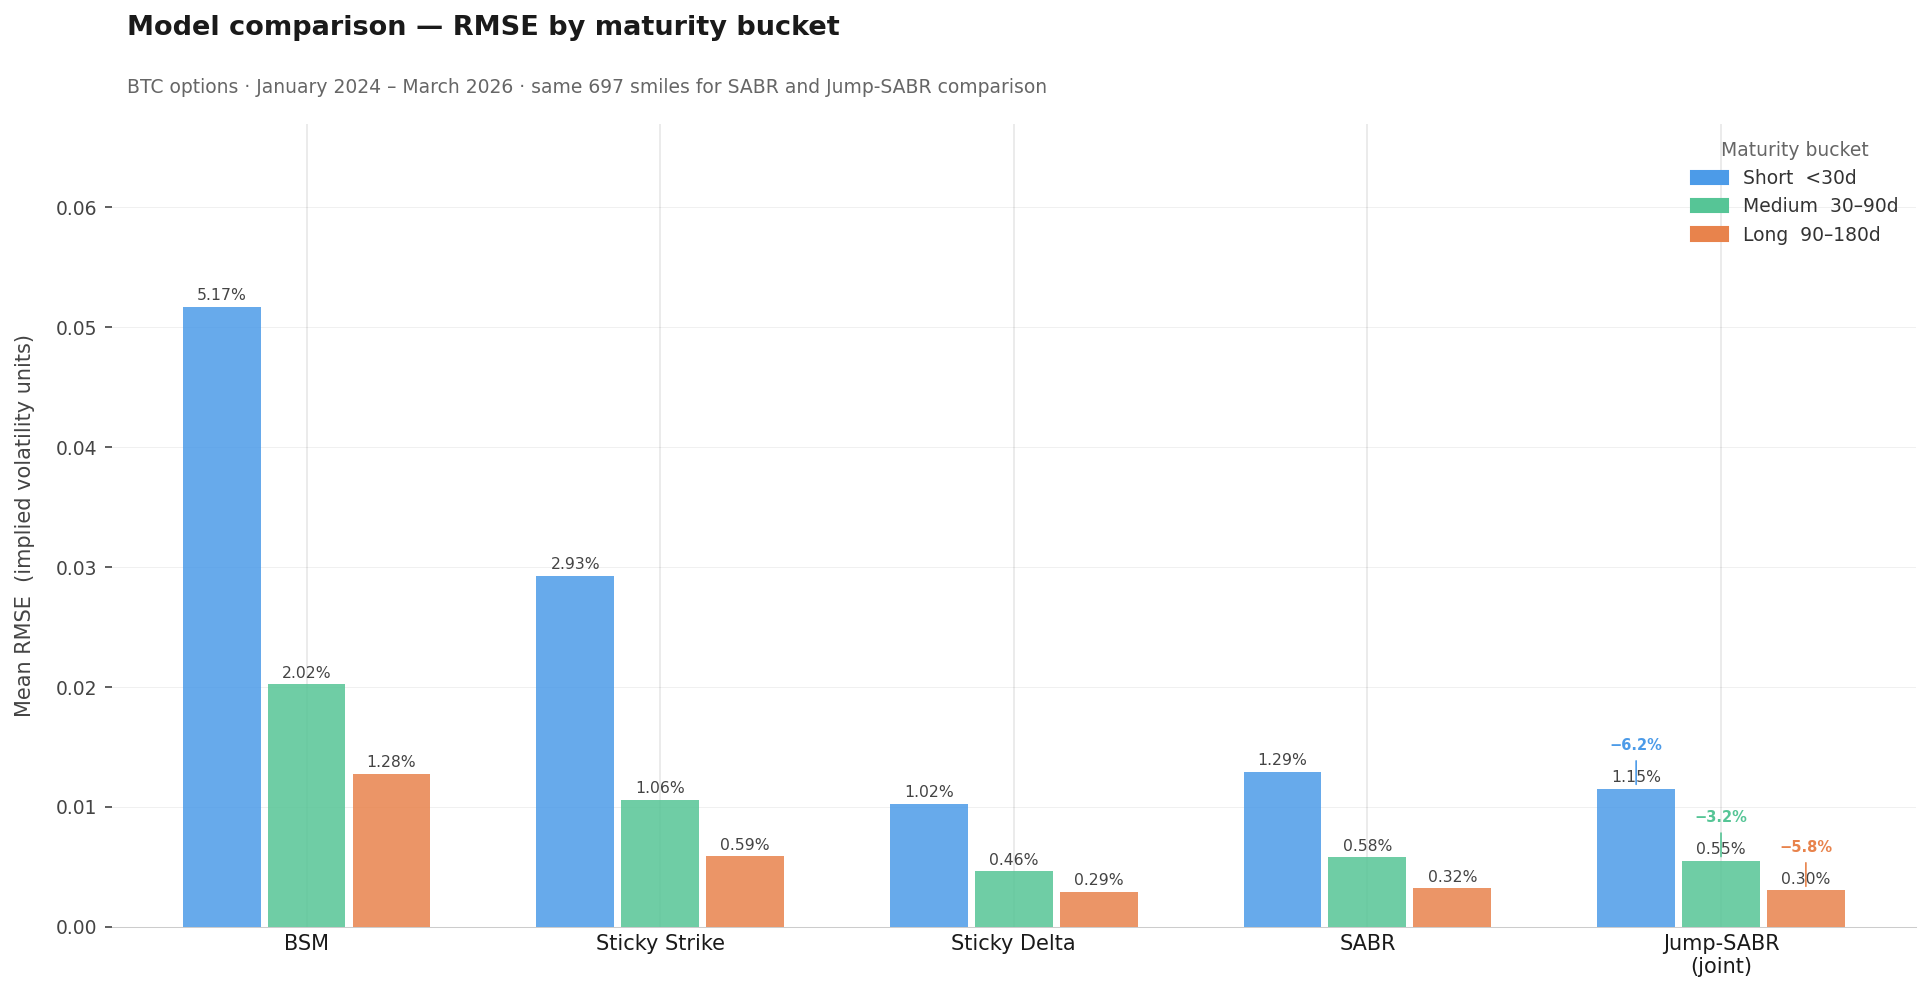

Plot 1 saved


In [63]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

models        = ['BSM', 'Sticky Strike', 'Sticky Delta', 'SABR', 'Jump-SABR\n(joint)']
bucket_labels = ['Short  <30d', 'Medium  30–90d', 'Long  90–180d']
palette       = ['#4C9BE8', '#56C596', '#E8834C']
buckets       = ['Short (<30d)', 'Medium (30-90d)', 'Long (90-180d)']

x     = np.arange(len(models))
width = 0.22
gap   = 0.02

for bi, (bucket, color) in enumerate(zip(buckets, palette)):
    row  = final_summary.loc[bucket]
    vals = [
        row['bsm'],
        row['sticky_strike'],
        row['sticky_delta'],
        row['sabr'],
        row['js_joint']
    ]
    offset = (bi - 1) * (width + gap)
    bars   = ax.bar(x + offset, vals, width,
                    color=color, alpha=0.85, zorder=3,
                    linewidth=0)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.0003,
                    f'{val*100:.2f}%',
                    ha='center', va='bottom',
                    fontsize=7.5, color='#444444')

# Improvement annotations
for bi, (bucket, color) in enumerate(zip(buckets, palette)):
    row    = final_summary.loc[bucket]
    imp    = row['improvement']
    offset = (bi - 1) * (width + gap)
    ax.annotate(f'−{imp:.1f}%',
                xy=(x[-1] + offset, row['js_joint']),
                xytext=(x[-1] + offset, row['js_joint'] + 0.003),
                fontsize=7, color=color, fontweight='bold',
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='-',
                               color=color, lw=0.8))

# Grid
ax.yaxis.grid(True, color='#000000', alpha=0.06,
              linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(models, color='#1a1a1a', fontsize=10)
ax.set_ylabel('Mean RMSE  (implied volatility units)',
              color='#444444', fontsize=10, labelpad=10)
ax.tick_params(axis='y', colors='#444444', labelsize=9)
ax.tick_params(axis='x', length=0)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['bottom'].set_linewidth(0.5)

# Legend
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(palette, bucket_labels)]
legend = ax.legend(handles=patches, loc='upper right',
                   framealpha=0, labelcolor='#333333',
                   fontsize=9, title='Maturity bucket',
                   title_fontsize=9)
legend.get_title().set_color('#666666')

ax.set_ylim(0, 0.067)
ax.set_xlim(-0.55, len(models) - 0.45)

# Title
fig.text(0.07, 0.96,
         'Model comparison — RMSE by maturity bucket',
         color='#1a1a1a', fontsize=13, fontweight='bold', va='top')
fig.text(0.07, 0.90,
         'BTC options · January 2024 – March 2026 · '
         f'same {int(final_summary["n_smiles"].sum())} smiles — identical dataset for all models',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.savefig('../results/plot1_rmse_comparison.png',
            dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print("Plot 1 saved")

In [ ]:
# ─────────────────────────────────────────────
# Sequential vs Joint calibration — identification plot
# Shows why sequential (SABR first, jumps second) collapses
# jump parameters to degenerate values, while joint calibration
# identifies meaningful jump dynamics.
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

df_seq   = pd.read_csv('../data/calibration_results.csv')
df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])

# Matched smiles only (same 697)
df = df_seq.merge(
    df_joint[['date','expiry','js_rmse','js_lam','js_muJ','js_delta']],
    on=['date','expiry'], suffixes=('_seq','_joint')
)

COLOR_SEQ   = '#E8834C'
COLOR_JOINT = '#4C9BE8'
COLOR_SABR  = '#999999'

fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#ffffff')

# ── Helper: KDE overlay plot ──
def kde_panel(ax, seq_vals, joint_vals, xlabel, xlim=None, log_scale=False):
    seq_vals   = np.array(seq_vals)
    joint_vals = np.array(joint_vals)
    if log_scale:
        seq_vals   = np.log(seq_vals[seq_vals > 0])
        joint_vals = np.log(joint_vals[joint_vals > 0])
    xs = np.linspace(
        min(seq_vals.min(), joint_vals.min()),
        max(seq_vals.max(), joint_vals.max()), 500
    )
    for vals, color, label in [
        (seq_vals,   COLOR_SEQ,   'Sequential'),
        (joint_vals, COLOR_JOINT, 'Joint'),
    ]:
        kde = gaussian_kde(vals, bw_method=0.15)
        ys  = kde(xs)
        ax.fill_between(xs, ys, alpha=0.25, color=color)
        ax.plot(xs, ys, color=color, linewidth=2, label=label)
        ax.axvline(np.median(vals), color=color, linewidth=1.2,
                   linestyle='--', alpha=0.8)
    if xlim:
        ax.set_xlim(xlim)
    if log_scale:
        ticks = ax.get_xticks()
        ax.set_xticklabels([f'{np.exp(t):.2f}' for t in ticks], fontsize=8)
        ax.set_xlabel(f'{xlabel}  (log scale)', fontsize=10)
    else:
        ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Density', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(labelsize=8)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_alpha(0.3)
    ax.spines['bottom'].set_alpha(0.3)
    ax.grid(axis='y', alpha=0.15, linewidth=0.5)

# ── Panel layout: 2 rows × 3 cols (top = distributions, bottom-left = RMSE) ──
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97, top=0.82, bottom=0.10)

ax_lam   = fig.add_subplot(gs[0, 0])
ax_muJ   = fig.add_subplot(gs[0, 1])
ax_delta = fig.add_subplot(gs[0, 2])
ax_rmse  = fig.add_subplot(gs[1, 0:2])
ax_imp   = fig.add_subplot(gs[1, 2])

# ── Jump parameter distributions ──
kde_panel(ax_lam,   df['js_lam_seq'],  df['js_lam_joint'],
          r'Jump intensity  $\lambda$', log_scale=True)
kde_panel(ax_muJ,   df['js_muJ_seq'],  df['js_muJ_joint'],
          r'Jump mean  $\mu_J$', xlim=(-1.0, 1.0))
kde_panel(ax_delta, df['js_delta_seq'], df['js_delta_joint'],
          r'Jump std  $\delta$', xlim=(0, 1.2))

ax_lam.set_title(r'$\lambda$ — Jump intensity', fontsize=10, pad=6, color='#333333')
ax_muJ.set_title(r'$\mu_J$ — Jump mean', fontsize=10, pad=6, color='#333333')
ax_delta.set_title(r'$\delta$ — Jump std dev', fontsize=10, pad=6, color='#333333')

# Add shared legend on lambda panel
ax_lam.legend(fontsize=8, framealpha=0, labelcolor='#333333')

# ── RMSE panel: per-smile scatter SABR vs seq vs joint ──
x = np.arange(len(df))
ax_rmse.scatter(x, df['sabr_rmse'],      s=2, alpha=0.4, color=COLOR_SABR,  label='SABR',           zorder=2)
ax_rmse.scatter(x, df['js_rmse_seq'],    s=2, alpha=0.4, color=COLOR_SEQ,   label='Jump-SABR (seq)', zorder=3)
ax_rmse.scatter(x, df['js_rmse_joint'],  s=2, alpha=0.6, color=COLOR_JOINT, label='Jump-SABR (joint)', zorder=4)
ax_rmse.set_xlabel('Smile index (sorted by date)', fontsize=9)
ax_rmse.set_ylabel('RMSE (IV units)', fontsize=9)
ax_rmse.set_title('Per-smile RMSE — all three models', fontsize=10, pad=6, color='#333333')
ax_rmse.set_ylim(0, 0.12)
ax_rmse.legend(fontsize=8, framealpha=0, labelcolor='#333333', markerscale=3)
ax_rmse.tick_params(labelsize=8)
for spine in ['top','right']:
    ax_rmse.spines[spine].set_visible(False)
ax_rmse.spines['left'].set_alpha(0.3)
ax_rmse.spines['bottom'].set_alpha(0.3)
ax_rmse.grid(axis='y', alpha=0.15, linewidth=0.5)

# ── Mean RMSE bar panel ──
means  = [df['sabr_rmse'].mean(), df['js_rmse_seq'].mean(), df['js_rmse_joint'].mean()]
labels = ['SABR', 'Jump-SABR\n(sequential)', 'Jump-SABR\n(joint)']
colors = [COLOR_SABR, COLOR_SEQ, COLOR_JOINT]
bars = ax_imp.bar(labels, means, color=colors, alpha=0.85, width=0.5, zorder=3)
for bar, val in zip(bars, means):
    ax_imp.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0002,
                f'{val*100:.3f}%',
                ha='center', va='bottom', fontsize=8.5, color='#444444')
# Improvement arrows
imp_seq   = (means[0] - means[1]) / means[0] * 100
imp_joint = (means[0] - means[2]) / means[0] * 100
ax_imp.text(1, means[1] + 0.0012, f'−{imp_seq:.1f}%',
            ha='center', fontsize=8, color=COLOR_SEQ, fontweight='bold')
ax_imp.text(2, means[2] + 0.0012, f'−{imp_joint:.1f}%',
            ha='center', fontsize=8, color=COLOR_JOINT, fontweight='bold')
ax_imp.set_ylabel('Mean RMSE (IV units)', fontsize=9)
ax_imp.set_title('Mean RMSE — matched 697 smiles', fontsize=10, pad=6, color='#333333')
ax_imp.tick_params(labelsize=8)
ax_imp.set_ylim(0, max(means) * 1.25)
for spine in ['top','right']:
    ax_imp.spines[spine].set_visible(False)
ax_imp.spines['left'].set_alpha(0.3)
ax_imp.spines['bottom'].set_alpha(0.3)
ax_imp.grid(axis='y', alpha=0.15, linewidth=0.5, zorder=0)
ax_imp.set_axisbelow(True)

# ── Titles ──
fig.text(0.07, 0.97,
         'Sequential vs Joint calibration — parameter identification',
         color='#1a1a1a', fontsize=13, fontweight='bold', va='top')
fig.text(0.07, 0.91,
         'Sequential calibration (SABR first, jumps second) collapses jump parameters to degenerate values.'
         '  Joint calibration identifies meaningful jump dynamics.',
         color='#666666', fontsize=9, va='top')

plt.savefig('../results/plot_seq_vs_joint_calibration.png',
            dpi=150, bbox_inches='tight', facecolor='#ffffff')
plt.show()
print(f'Sequential: mean js_lam = {df["js_lam_seq"].median():.4f} (median), '
      f'99.8% > 0.9  →  degenerate')
print(f'Joint:      mean js_lam = {df["js_lam_joint"].median():.4f} (median), '
      f'wide spread  →  identified')
print(f'RMSE improvement — seq: {imp_seq:.1f}%,  joint: {imp_joint:.1f}%')
print('Plot saved to results/plot_seq_vs_joint_calibration.png')


In [ ]:
# ─────────────────────────────────────────────
# Plot 8 — Out-of-sample day-ahead prediction
# Calibrate on day t → predict day t+1 smile (same expiry)
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import sys, os, time
sys.path.insert(0, '..')
from src.sabr import hagan_vol
from src.jump_sabr import jump_sabr_implied_vol

OOS_CSV = '../data/oos_results.csv'

if os.path.exists(OOS_CSV):
    df_oos = pd.read_csv(OOS_CSV)
    print(f'Loaded from disk: {len(df_oos)} smile-pairs')
else:
    df_cal = pd.read_csv('../data/calibration_results.csv')
    df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
    df_mkt['expiry'] = pd.to_datetime(df_mkt['expiry']).dt.strftime('%Y-%m-%d')
    df_mkt['date']   = pd.to_datetime(df_mkt['date']).dt.strftime('%Y-%m-%d')
    df_bench = pd.read_csv('../data/benchmark_results.csv')

    df_cal = df_cal.sort_values(['expiry','date']).reset_index(drop=True)
    rows, start = [], time.time()

    for expiry, grp in df_cal.groupby('expiry'):
        grp = grp.sort_values('date').reset_index(drop=True)
        exp_str = str(expiry)[:10]
        for i in range(1, len(grp)):
            today = grp.iloc[i]; yest = grp.iloc[i-1]
            mkt = df_mkt[(df_mkt['date']==today['date']) & (df_mkt['expiry']==exp_str)]
            if len(mkt) < 4: continue
            K_arr    = mkt['strike'].values.astype(float)
            mv       = mkt['mark_iv'].values.astype(float)
            F_today  = float(mkt['index_price'].mean())
            T        = float(today['T'])

            # Model OOS
            sabr_p = np.array([hagan_vol(F_today,K,T,
                float(yest['sabr_alpha']),1.0,float(yest['sabr_rho']),float(yest['sabr_nu']))
                for K in K_arr])
            sabr_p = np.where((sabr_p>0.01)&(sabr_p<5), sabr_p, np.nan)

            js_p = np.array([jump_sabr_implied_vol(F_today,K,T,0,
                float(yest['js_alpha']),1.0,float(yest['js_rho']),float(yest['js_nu']),
                float(yest['js_lam']),float(yest['js_muJ']),float(yest['js_delta']),15)
                for K in K_arr])
            js_p = np.where((js_p>0.01)&(js_p<5), js_p, np.nan)

            # Sticky benchmarks (raw market interpolation)
            ym = df_mkt[(df_mkt['date']==yest['date']) & (df_mkt['expiry']==exp_str)]
            ss_p = sd_p = np.full(len(K_arr), np.nan)
            if len(ym) >= 3:
                yk = ym['strike'].values.astype(float)
                yv = ym['mark_iv'].values.astype(float)
                Fy = float(ym['index_price'].mean())
                ylog = np.log(yk/Fy); sidx = np.argsort(ylog)
                ylog_s, yv_s = ylog[sidx], yv[sidx]
                # Sticky Strike: same absolute strike → same log(K/F_yest)
                x_ss = np.log(K_arr/Fy)
                ok = (x_ss>=ylog_s[0])&(x_ss<=ylog_s[-1])
                ss_p = np.where(ok, np.interp(x_ss, ylog_s, yv_s), np.nan)
                # Sticky Delta: same log-moneyness K/F_today
                x_sd = np.log(K_arr/F_today)
                ok2 = (x_sd>=ylog_s[0])&(x_sd<=ylog_s[-1])
                sd_p = np.where(ok2, np.interp(x_sd, ylog_s, yv_s), np.nan)

            def rmse(p,a):
                m = ~np.isnan(p); return float(np.sqrt(np.mean((p[m]-a[m])**2))) if m.sum()>=3 else np.nan

            rows.append({'date':today['date'],'expiry':exp_str,'T':T,'T_days':T*365,
                'sabr_oos':rmse(sabr_p,mv),'js_oos':rmse(js_p,mv),
                'sticky_strike_oos':rmse(ss_p,mv),'sticky_delta_oos':rmse(sd_p,mv),
                'sabr_is':float(today['sabr_rmse']),'js_is':float(today['js_rmse'])})

    df_oos = pd.DataFrame(rows).dropna(
        subset=['sabr_oos','js_oos','sticky_strike_oos','sticky_delta_oos'])

    # Merge IS benchmark RMSEs for the same smiles
    df_oos = df_oos.merge(
        df_bench[['date','expiry','T','sticky_strike_rmse','sticky_delta_rmse']],
        on=['date','expiry','T'], how='left')
    df_oos.to_csv(OOS_CSV, index=False)
    print(f'OOS computed: {len(df_oos)} pairs in {(time.time()-start)/60:.1f} min')

print('\nMean IS RMSE:')
print(f'  Sticky Strike IS: {df_oos["sticky_strike_rmse"].mean():.6f}')
print(f'  Sticky Delta  IS: {df_oos["sticky_delta_rmse"].mean():.6f}')
print(f'  SABR          IS: {df_oos["sabr_is"].mean():.6f}')
print(f'  JS-seq        IS: {df_oos["js_is"].mean():.6f}')
print('\nMean OOS RMSE:')
print(f'  Sticky Strike OOS: {df_oos["sticky_strike_oos"].mean():.6f}')
print(f'  Sticky Delta  OOS: {df_oos["sticky_delta_oos"].mean():.6f}')
print(f'  SABR          OOS: {df_oos["sabr_oos"].mean():.6f}')
print(f'  JS-seq        OOS: {df_oos["js_oos"].mean():.6f}')


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df_oos = pd.read_csv('../data/oos_results.csv')

models   = ['Sticky Strike', 'Sticky Delta', 'SABR', 'JS-seq']
is_cols  = ['sticky_strike_rmse', 'sticky_delta_rmse', 'sabr_is', 'js_is']
oos_cols = ['sticky_strike_oos', 'sticky_delta_oos', 'sabr_oos', 'js_oos']
colors   = ['#aaaaaa', '#56C596', '#4C9BE8', '#E8834C']

is_means  = np.array([df_oos[c].mean() for c in is_cols])
oos_means = np.array([df_oos[c].mean() for c in oos_cols])

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          gridspec_kw={'width_ratios': [1.6, 1]})
fig.patch.set_facecolor('#ffffff')

# ── Left: slopegraph IS → OOS ──────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#ffffff')

X_IS, X_OOS = 0, 1

for i, (model, col, is_v, oos_v) in enumerate(
        zip(models, colors, is_means, oos_means)):
    # Connecting line
    ax.plot([X_IS, X_OOS], [is_v*100, oos_v*100],
            color=col, linewidth=2.2, alpha=0.85, zorder=3)
    # Dots
    ax.scatter([X_IS],  [is_v*100],  s=90, color=col, zorder=5)
    ax.scatter([X_OOS], [oos_v*100], s=90, color=col, zorder=5)
    # Left labels
    ax.text(X_IS - 0.04, is_v*100,
            f'{model}\n{is_v*100:.2f}%',
            ha='right', va='center', fontsize=9, color=col, fontweight='bold')
    # Right labels
    ax.text(X_OOS + 0.04, oos_v*100,
            f'{oos_v*100:.2f}%\n(+{(oos_v-is_v)*100:.2f}pp)',
            ha='left', va='center', fontsize=9, color=col, fontweight='bold')

# Column headers
ax.text(X_IS,  ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else max(is_means)*100*1.15,
        'In-sample', ha='center', va='bottom', fontsize=11,
        fontweight='bold', color='#333333')
ax.text(X_OOS, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else max(is_means)*100*1.15,
        'Out-of-sample\n(day-ahead)', ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333')

# Manually set limits so labels don't clip
y_min = min(is_means.min(), oos_means.min())*100 * 0.85
y_max = max(is_means.max(), oos_means.max())*100 * 1.18
ax.set_ylim(y_min, y_max)
ax.set_xlim(-0.55, 1.55)

# Column header lines
ax.axvline(X_IS,  color='#cccccc', linewidth=1, zorder=1)
ax.axvline(X_OOS, color='#cccccc', linewidth=1, zorder=1)

ax.set_ylabel('Mean RMSE  (×100 = % implied vol)', fontsize=10)
ax.set_xticks([])
ax.set_title('RMSE ranking: in-sample vs out-of-sample',
             fontsize=11, color='#1a1a1a', pad=10)
for s in ax.spines.values(): s.set_visible(False)
ax.grid(axis='y', alpha=0.12, linewidth=0.5)

# ── Right: absolute OOS RMSE bar chart (the number that matters) ────────────
ax2 = axes[1]
# Sort by OOS RMSE descending so worst is on top
order = np.argsort(oos_means)[::-1]
models_s  = [models[i]  for i in order]
oos_s     = oos_means[order] * 100
colors_s  = [colors[i]  for i in order]
is_s      = is_means[order] * 100

y = np.arange(len(models_s))
bars_oos = ax2.barh(y, oos_s, height=0.4, color=colors_s, alpha=0.9, zorder=3, label='OOS')
bars_is  = ax2.barh(y - 0.42, is_s, height=0.4, color=colors_s, alpha=0.35, zorder=2, label='IS')

for bar, v in zip(bars_oos, oos_s):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{v:.2f}%', va='center', fontsize=8.5, color='#333')
for bar, v in zip(bars_is, is_s):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{v:.2f}%', va='center', fontsize=8.5, color='#aaa')

ax2.set_yticks(y - 0.21)
ax2.set_yticklabels(models_s, fontsize=9)
ax2.set_xlabel('Mean RMSE (%)', fontsize=10)
ax2.set_title('OOS RMSE  (solid)\nvs IS RMSE  (faded)', fontsize=11, color='#1a1a1a', pad=10)
ax2.legend(fontsize=8, framealpha=0, loc='lower right')
for s in ['top', 'right']: ax2.spines[s].set_visible(False)
ax2.grid(axis='x', alpha=0.12, linewidth=0.5)
ax2.set_axisbelow(True)

fig.text(0.04, 0.97,
         'Out-of-sample validation — day-ahead smile prediction',
         fontsize=13, fontweight='bold', color='#1a1a1a', va='top')
fig.text(0.04, 0.91,
         'Left: each line = one model; slope shows how much RMSE degrades from IS to OOS.  '
         'Sticky Delta has the steepest rise — it memorises the past surface but does not generalise.',
         fontsize=9, color='#666666', va='top')

plt.tight_layout(rect=[0, 0, 1, 0.89])
plt.savefig('../results/plot8_out_of_sample.png', dpi=150,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()
print('Plot 8 saved')
print()
print('IS vs OOS summary:')
for m, i, o in zip(models, is_means, oos_means):
    print(f'  {m:15s}: IS={i*100:.2f}%  OOS={o*100:.2f}%  degradation=+{(o-i)*100:.2f}pp')


In [ ]:
# ─────────────────────────────────────────────
# Plot 9 — Realized jump validation
# Does implied λ correlate with subsequent realized BTC volatility / jump activity?
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

# Daily BTC returns
df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_mkt['date'] = pd.to_datetime(df_mkt['date'])
spot = df_mkt.groupby('date')['index_price'].last().reset_index().sort_values('date').reset_index(drop=True)
spot['log_ret'] = np.log(spot['index_price']/spot['index_price'].shift(1))
sig_r = spot['log_ret'].rolling(30).std()
spot['jump_2sig'] = (spot['log_ret'].abs() > 2.0*sig_r).astype(int)

# Implied λ: medium-term (20-60d) average per week-date
lam_mid = df_j[(df_j['T']*365>=20)&(df_j['T']*365<=60)]
lam_d = lam_mid.groupby('date')['js_lam'].mean().reset_index()

# Forward-looking: realized vol and jump count in the NEXT 5 trading days
spot_idx = spot.set_index('date')
def fwd_stats(d):
    future = spot_idx.loc[d+pd.Timedelta('1d'):d+pd.Timedelta('7d')]
    if len(future) < 3: return np.nan, np.nan
    return float(future['log_ret'].std()*np.sqrt(252)), int(future['jump_2sig'].sum())

lam_d[['fwd_rv','fwd_jumps']] = lam_d['date'].apply(
    lambda d: pd.Series(fwd_stats(d)))
df_v = lam_d.merge(spot[['date','log_ret','jump_2sig']], on='date', how='inner').dropna()

fig, axes = plt.subplots(1,3,figsize=(16,6))
fig.patch.set_facecolor('#ffffff')

# Panel 1: λ over time + realized jumps (dots)
ax = axes[0]
ax.plot(df_v['date'], df_v['js_lam'], '-o', color='#4C9BE8',
        linewidth=1.2, markersize=4, alpha=0.8, zorder=3)
ax.plot(df_v['date'], df_v['js_lam'].rolling(4).mean(),
        color='#1a4f8a', linewidth=2, zorder=4, label='4-week MA')
# Overlay realized jump dates
jump_dates = spot[spot['jump_2sig']==1]['date']
for jd in jump_dates:
    ax.axvline(jd, color='#E8834C', alpha=0.3, linewidth=1, zorder=2)
ax.set_ylabel(r'Implied $\lambda$ (jumps/year)', fontsize=9)
ax.set_title(r'Implied $\lambda$ over time  (orange lines = realized jumps |r|>2σ)', fontsize=9, color='#333')
ax.legend(fontsize=8, framealpha=0)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.get_xticklabels(), rotation=30, fontsize=7)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', alpha=0.1)

# Panel 2: λ vs forward 5-day realized vol (scatter + regression)
ax2 = axes[1]
mask = np.isfinite(df_v['fwd_rv'])&np.isfinite(df_v['js_lam'])
x2, y2 = df_v['js_lam'][mask].values, df_v['fwd_rv'][mask].values*100
ax2.scatter(x2, y2, s=30, alpha=0.55, color='#4C9BE8', zorder=3)
slope,intercept,r,p,_ = stats.linregress(x2,y2)
xline = np.linspace(x2.min(),x2.max(),100)
ax2.plot(xline, slope*xline+intercept, color='#E8834C', linewidth=2,
         label=f'r={r:.2f},  p={p:.3f}')
ax2.set_xlabel(r'Implied $\lambda$ (calibrated Friday)', fontsize=9)
ax2.set_ylabel('5-day forward realized vol (annualized %)', fontsize=9)
ax2.set_title(r'Does implied $\lambda$ predict near-term realized vol?', fontsize=9, color='#333')
ax2.legend(fontsize=9, framealpha=0)
for s in ['top','right']: ax2.spines[s].set_visible(False)
ax2.grid(alpha=0.1)

# Panel 3: λ distribution on jump weeks vs quiet weeks
ax3 = axes[2]
df_v['is_jump_week'] = (df_v['fwd_jumps'] > 0).astype(int)
grp_j  = df_v[df_v['is_jump_week']==1]['js_lam']
grp_nj = df_v[df_v['is_jump_week']==0]['js_lam']
np.random.seed(42)
def jitter(n): return np.random.uniform(-0.15,0.15,n)
ax3.scatter(0+jitter(len(grp_nj)), grp_nj, s=22, alpha=0.4, color='#4C9BE8', zorder=2)
ax3.scatter(1+jitter(len(grp_j)),  grp_j,  s=22, alpha=0.6, color='#E8834C', zorder=2)
ax3.hlines(grp_nj.mean(), -0.3,0.3, color='#1a4f8a', linewidth=2.5, zorder=4,
           label=f'Mean (quiet): {grp_nj.mean():.2f}')
ax3.hlines(grp_j.mean(),   0.7,1.3, color='#c04a00', linewidth=2.5, zorder=4,
           label=f'Mean (jump week): {grp_j.mean():.2f}')
t_s,p_v = stats.ttest_ind(grp_j.dropna(), grp_nj.dropna())
ax3.set_xticks([0,1])
ax3.set_xticklabels([f'Quiet weeks\n(n={len(grp_nj)})',
                     f'Jump weeks\n(n={len(grp_j)},  |r|>2σ)'], fontsize=9)
ax3.set_ylabel(r'Implied $\lambda$', fontsize=9)
ax3.set_title(f'λ on weeks preceding realized jumps\n(t-test p={p_v:.3f})', fontsize=9, color='#333')
ax3.legend(fontsize=8, framealpha=0, loc='upper right')
for s in ['top','right']: ax3.spines[s].set_visible(False)
ax3.grid(axis='y', alpha=0.1)

fig.text(0.05,0.97,'Realized jump validation — does implied λ capture realized BTC jump risk?',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'λ calibrated each Friday on 20–60d options.  '
         'Forward realized vol and jump counts computed over the next 5 trading days.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot9_realized_jump_validation.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print(f'Correlation λ vs forward RV: r={r:.3f}, p={p_v:.4f}')
print('Plot 9 saved')


In [ ]:
# ─────────────────────────────────────────────
# Plot 10 — Event windows: λ, μ_J, δ around key BTC market events
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

# Aggregate across maturities per date
daily = df_j.groupby('date').agg(
    lam=('js_lam','median'), muJ=('js_muJ','median'), delta=('js_delta','median')
).reset_index()

events = [
    ('2024-01-10', 'ETF\nApproval',  '#4C9BE8'),
    ('2024-04-20', 'BTC\nHalving',   '#56C596'),
    ('2024-11-05', 'US\nElection',   '#E8834C'),
    ('2025-01-20', 'Trump\nInaugur.','#9B6BE8'),
]
WINDOW = 21  # days either side

params = [('lam', r'$\lambda$ (jump intensity)', '#4C9BE8'),
          ('muJ', r'$\mu_J$ (jump mean)',         '#56C596'),
          ('delta', r'$\delta$ (jump std)',        '#E8834C')]

fig, axes = plt.subplots(3,4,figsize=(16,10),sharey='row')
fig.patch.set_facecolor('#ffffff')

for col, (edate, ename, ecol) in enumerate(events):
    ed = pd.Timestamp(edate)
    window = daily[(daily['date']>=ed-pd.Timedelta(f'{WINDOW}d'))&
                   (daily['date']<=ed+pd.Timedelta(f'{WINDOW}d'))].copy()
    window['days'] = (window['date']-ed).dt.days

    for row, (param, ylabel, pcol) in enumerate(params):
        ax = axes[row][col]
        if len(window) > 0:
            ax.plot(window['days'], window[param], 'o-',
                    color=pcol, linewidth=1.5, markersize=5, zorder=3)
            # Fill pre/post event
            pre  = window[window['days']<=0]
            post = window[window['days']>=0]
            if len(pre)>1:  ax.fill_between(pre['days'],  pre[param],  alpha=0.12, color=pcol)
            if len(post)>1: ax.fill_between(post['days'], post[param], alpha=0.12, color=ecol)
        ax.axvline(0, color=ecol, linewidth=1.5, linestyle='--', alpha=0.8, zorder=4)
        ax.axhline(daily[param].median(), color='#999', linewidth=0.8,
                   linestyle=':', alpha=0.6, label='Full-sample median')
        if row==0: ax.set_title(ename, fontsize=10, fontweight='bold', color=ecol, pad=6)
        if col==0: ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel('Days relative to event', fontsize=8)
        ax.tick_params(labelsize=7)
        for s in ['top','right']: ax.spines[s].set_visible(False)
        ax.grid(alpha=0.1)

# Add legend once
axes[0][0].plot([],[],color='#999',linestyle=':',label='Full-sample median')
axes[0][0].legend(fontsize=7,framealpha=0)

fig.text(0.05,0.98,
         'Jump parameter dynamics around key BTC market events  (±14 days)',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.93,
         'Dashed vertical line = event date.  Dotted horizontal = full-sample median.'
         '  Each point = median across maturities on that Friday.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.91])
plt.savefig('../results/plot10_event_windows.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print('Plot 10 saved')


In [ ]:
# ─────────────────────────────────────────────
# Plot 11 — VRP decomposition: SABR vs Jump contribution to ATM IV
# Jump contribution = JS_ATM_IV − SABR_ATM_IV
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.insert(0, '..')
from src.sabr import hagan_vol
from src.jump_sabr import jump_sabr_implied_vol

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

# For each smile compute ATM SABR IV and ATM JS IV
atm_rows = []
for _, r in df_j.iterrows():
    F, T = r['F'], r['T']
    sabr_atm = hagan_vol(F,F,T, r['js_alpha'],1.0,r['js_rho'],r['js_nu'])
    js_atm   = jump_sabr_implied_vol(F,F,T,0, r['js_alpha'],1.0,r['js_rho'],r['js_nu'],
                                     r['js_lam'],r['js_muJ'],r['js_delta'],15)
    atm_rows.append({'date':r['date'],'T':r['T'],
                     'sabr_atm':sabr_atm,'js_atm':js_atm,
                     'jump_contrib':js_atm-sabr_atm})
df_atm = pd.DataFrame(atm_rows)

# Aggregate to daily (median across maturities)
daily_atm = df_atm.groupby('date').agg(
    sabr_atm=('sabr_atm','median'),
    js_atm=('js_atm','median'),
    jump_contrib=('jump_contrib','median')
).reset_index()

# Add realized vol
df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_mkt['date'] = pd.to_datetime(df_mkt['date'])
spot = df_mkt.groupby('date')['index_price'].last().reset_index()
spot = spot.sort_values('date')
spot['log_ret'] = np.log(spot['index_price']/spot['index_price'].shift(1))
spot['rv_30d'] = spot['log_ret'].rolling(30).std()*np.sqrt(365)
spot.columns = ['date','spot','log_ret','rv_30d']

df_vrp = daily_atm.merge(spot[['date','rv_30d']], on='date', how='inner').dropna()

fig, axes = plt.subplots(2,1,figsize=(14,9),sharex=True)
fig.patch.set_facecolor('#ffffff')

# Panel 1: SABR ATM IV decomposed into SABR base + Jump
ax = axes[0]
ax.stackplot(df_vrp['date'],
             df_vrp['sabr_atm']*100,
             df_vrp['jump_contrib']*100,
             labels=['SABR base (stochastic vol)','Jump contribution'],
             colors=['#4C9BE8','#E8834C'], alpha=0.75)
ax.plot(df_vrp['date'], df_vrp['rv_30d']*100,
        color='#333333', linewidth=1.5, linestyle='--', label='30-day realized vol', zorder=5)
ax.set_ylabel('ATM implied volatility (%)',fontsize=10)
ax.set_title('ATM IV decomposition: SABR stochastic-vol base + jump contribution',
             fontsize=11,color='#1a1a1a')
ax.legend(fontsize=9,framealpha=0,loc='upper left')
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(axis='y',alpha=0.1)

# Panel 2: Jump contribution as % of total IV
ax2 = axes[1]
df_vrp['jump_pct'] = df_vrp['jump_contrib']/df_vrp['js_atm']*100
ax2.bar(df_vrp['date'], df_vrp['jump_pct'],
        color=np.where(df_vrp['jump_pct']>0,'#E8834C','#4C9BE8'),
        alpha=0.7, width=7, zorder=2)
ax2.axhline(df_vrp['jump_pct'].mean(), color='#333', linewidth=1.5, linestyle='--',
             label=f'Mean: {df_vrp["jump_pct"].mean():.1f}%')
ax2.set_ylabel('Jump contrib as % of total ATM IV',fontsize=10)
ax2.set_title('Share of ATM implied vol explained by jump component',
              fontsize=11,color='#1a1a1a')
ax2.legend(fontsize=9,framealpha=0)
for s in ['top','right']: ax2.spines[s].set_visible(False)
ax2.grid(axis='y',alpha=0.1)

events = {'2024-01-10':'ETF','2024-04-20':'Halving','2024-11-05':'Election','2025-01-20':'Inaugur.'}
for ax_i in axes:
    for ed, lab in events.items():
        ax_i.axvline(pd.Timestamp(ed),color='#999',alpha=0.4,linewidth=1,linestyle='--')
ylim = axes[0].get_ylim()
for ed, lab in events.items():
    axes[0].text(pd.Timestamp(ed),ylim[1]*0.97,lab,fontsize=7,color='#888',ha='center',va='top')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)

fig.text(0.05,0.97,'VRP decomposition — SABR stochastic-vol vs jump contribution to ATM IV',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('../results/plot11_vrp_decomposition.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print(f'Mean jump contribution: {df_vrp["jump_contrib"].mean()*100:.2f}% IV pts')
print(f'Mean jump share of total ATM IV: {df_vrp["jump_pct"].mean():.1f}%')
print('Plot 11 saved')


In [ ]:
# ─────────────────────────────────────────────
# Merton (1976) calibration on the same 697 weekly smiles
# Allows direct Merton vs Jump-SABR comparison on same dataset
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import sys, os, time
sys.path.insert(0, '..')
from src.merton import calibrate_merton
from src.data_loader import get_smile_slice

MERTON_CSV = '../data/merton_weekly.csv'

if os.path.exists(MERTON_CSV):
    df_merton = pd.read_csv(MERTON_CSV)
    print(f'Loaded from disk: {len(df_merton)} Merton fits')
else:
    df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
    df_smile = pd.read_csv('../data/btc_daily_smile.csv')
    df_smile['expiry'] = pd.to_datetime(df_smile['expiry'])
    df_smile['date']   = pd.to_datetime(df_smile['date']).dt.strftime('%Y-%m-%d')

    rows, errs, start = [], [], time.time()
    total = len(df_joint)

    for idx, (_, row) in enumerate(df_joint.iterrows()):
        date   = str(row['date'])[:10]
        expiry = row['expiry']
        try:
            strikes, vols, F, T = get_smile_slice(df_smile, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6: continue
            mp, mr = calibrate_merton(F, T, strikes, vols, n_terms=20)
            rows.append({'date':date,'expiry':str(expiry)[:10],'T':round(T,4),
                'merton_sigma':round(mp['sigma'],4),'merton_lam':round(mp['lam'],4),
                'merton_muJ':round(mp['mu_J'],4),'merton_delta':round(mp['delta'],4),
                'merton_rmse':round(mr,6),
                'sabr_rmse':row['sabr_rmse'],'js_rmse':row['js_rmse']})
        except Exception as e:
            errs.append({'date':date,'expiry':str(expiry)[:10],'error':str(e)})

        if (idx+1) % 50 == 0:
            elapsed = time.time()-start
            eta = (total-idx-1)/((idx+1)/elapsed)/60
            print(f'  {idx+1}/{total} | Merton: {np.mean([r["merton_rmse"] for r in rows]):.4f} | ETA: {eta:.0f} min')

    df_merton = pd.DataFrame(rows)
    df_merton.to_csv(MERTON_CSV, index=False)
    print(f'Done: {len(df_merton)} fits ({len(errs)} errors) in {(time.time()-start)/60:.1f} min')

print(f'\nMean RMSE comparison (same {len(df_merton)} smiles):')
print(f'  Merton:    {df_merton["merton_rmse"].mean():.6f}')
print(f'  SABR:      {df_merton["sabr_rmse"].mean():.6f}')
print(f'  JS-joint:  {df_merton["js_rmse"].mean():.6f}')


In [ ]:
# ─────────────────────────────────────────────
# Plot 12 — Full model horse-race including Merton
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_merton = pd.read_csv('../data/merton_weekly.csv')
df_bench  = pd.read_csv('../data/benchmark_results.csv')

df_m = df_merton.merge(
    df_bench[['date','expiry','T','bsm_rmse','sticky_strike_rmse','sticky_delta_rmse']],
    on=['date','expiry','T'], how='left'
).dropna(subset=['merton_rmse','bsm_rmse'])

df_m['T_bucket'] = pd.cut(df_m['T']*365,bins=[0,30,90,180],
    labels=['Short (<30d)','Medium (30-90d)','Long (90-180d)'])

models  = ['BSM','Sticky\nStrike','Sticky\nDelta','Merton','SABR','Jump-SABR']
rm_cols = ['bsm_rmse','sticky_strike_rmse','sticky_delta_rmse','merton_rmse','sabr_rmse','js_rmse']
palette = ['#4C9BE8','#56C596','#E8834C']
buckets = ['Short (<30d)','Medium (30-90d)','Long (90-180d)']
bucket_labels = ['Short  <30d','Medium  30–90d','Long  90–180d']

fig, ax = plt.subplots(figsize=(14,7))
fig.patch.set_facecolor('#ffffff')
x = np.arange(len(models)); width=0.22; gap=0.02

for bi,(bucket,color) in enumerate(zip(buckets,palette)):
    sub  = df_m[df_m['T_bucket']==bucket]
    vals = [sub[c].mean() for c in rm_cols]
    off  = (bi-1)*(width+gap)
    bars = ax.bar(x+off, vals, width, color=color, alpha=0.85, zorder=3, linewidth=0)
    for bar,v in zip(bars,vals):
        if not np.isnan(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                    f'{v*100:.2f}%',ha='center',va='bottom',fontsize=6.5,color='#444')

ax.set_xticks(x); ax.set_xticklabels(models,fontsize=9,color='#1a1a1a')
ax.set_ylabel('Mean RMSE (IV units)',fontsize=10,labelpad=10)
ax.tick_params(axis='y',labelsize=9); ax.tick_params(axis='x',length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color('#ccc')
ax.yaxis.grid(True,color='#000',alpha=0.06,linewidth=0.5,zorder=0); ax.set_axisbelow(True)

patches = [mpatches.Patch(color=c,label=l) for c,l in zip(palette,bucket_labels)]
legend = ax.legend(handles=patches,loc='upper right',framealpha=0,labelcolor='#333',
                   fontsize=9,title='Maturity bucket',title_fontsize=9)
legend.get_title().set_color('#666')

fig.text(0.07,0.96,'Model horse-race — RMSE by maturity bucket  (inc. Merton)',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.07,0.90,f'BTC options · same {len(df_m)} smiles for all models',
         fontsize=9,color='#666',va='top')

plt.tight_layout(rect=[0,0.02,1,0.88])
plt.savefig('../results/plot12_model_horse_race.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print('Plot 12 saved')


In [ ]:
# ─────────────────────────────────────────────
# Plot 13 — Beta robustness check
# Re-run SABR + JS with β = 0.5, 0.7, 1.0 on stratified sample
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os, time
sys.path.insert(0, '..')
from src.sabr import calibrate_sabr
from src.jump_sabr import calibrate_jump_sabr
from src.data_loader import get_smile_slice

BETA_CSV = '../data/beta_robustness.csv'

if os.path.exists(BETA_CSV):
    df_beta = pd.read_csv(BETA_CSV)
    print(f'Loaded from disk: {len(df_beta)} rows')
else:
    df_joint = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
    df_smile = pd.read_csv('../data/btc_daily_smile.csv')
    df_smile['expiry'] = pd.to_datetime(df_smile['expiry'])
    df_smile['date']   = pd.to_datetime(df_smile['date']).dt.strftime('%Y-%m-%d')

    # Stratified sample: 30 smiles per T-bucket (~90 total)
    df_joint['T_days'] = df_joint['T']*365
    df_joint['T_bucket'] = pd.cut(df_joint['T_days'],bins=[0,30,90,180],
        labels=['Short','Medium','Long'])
    sample = df_joint.dropna(subset=['T_bucket']).groupby('T_bucket',observed=True).apply(
        lambda g: g.sample(min(30,len(g)),random_state=42)).reset_index(drop=True)
    print(f'Running beta robustness on {len(sample)} smiles...')

    rows, start = [], time.time()
    for _, row in sample.iterrows():
        date, expiry = str(row['date'])[:10], row['expiry']
        try:
            strikes, vols, F, T = get_smile_slice(df_smile, date, expiry, iv_col='mark_iv')
            if len(strikes) < 6: continue
            for beta in [0.5, 0.7, 1.0]:
                _, sabr_r = calibrate_sabr(F, T, strikes, vols, beta=beta)
                _, js_r   = calibrate_jump_sabr(F, T, strikes, vols, beta=beta, n_terms=15)
                rows.append({'date':date,'expiry':str(expiry)[:10],'T':T,
                             'T_bucket':row['T_bucket'],'beta':beta,
                             'sabr_rmse':sabr_r,'js_rmse':js_r})
        except: continue

    df_beta = pd.DataFrame(rows)
    df_beta.to_csv(BETA_CSV, index=False)
    print(f'Done in {(time.time()-start)/60:.1f} min')

# Plot
fig, axes = plt.subplots(1,3,figsize=(14,5),sharey=False)
fig.patch.set_facecolor('#ffffff')
betas  = [0.5, 0.7, 1.0]
colors = ['#4C9BE8','#56C596','#E8834C']
buckets = ['Short','Medium','Long']

for bi, bucket in enumerate(buckets):
    ax = axes[bi]
    sub = df_beta[df_beta['T_bucket']==bucket]
    sabr_means = [sub[sub['beta']==b]['sabr_rmse'].mean() for b in betas]
    js_means   = [sub[sub['beta']==b]['js_rmse'].mean()   for b in betas]
    x = np.arange(len(betas)); w = 0.35
    b1 = ax.bar(x-w/2, sabr_means, w, color='#4C9BE8', alpha=0.85, label='SABR', zorder=3)
    b2 = ax.bar(x+w/2, js_means,   w, color='#E8834C', alpha=0.85, label='JS-seq', zorder=3)
    for bar,v in list(zip(b1,sabr_means))+list(zip(b2,js_means)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                f'{v*100:.3f}%',ha='center',va='bottom',fontsize=7.5,color='#444')
    ax.set_xticks(x); ax.set_xticklabels([f'β={b}' for b in betas],fontsize=9)
    ax.set_title(f'{bucket} maturity',fontsize=10,color='#1a1a1a')
    ax.set_ylabel('Mean RMSE (IV units)',fontsize=9)
    if bi==0: ax.legend(fontsize=8,framealpha=0)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    ax.grid(axis='y',alpha=0.12); ax.set_axisbelow(True)

fig.text(0.05,0.97,'Beta robustness check — RMSE is stable across β ∈ {0.5, 0.7, 1.0}',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'SABR and Jump-SABR (sequential) re-calibrated with different CEV elasticity β on stratified sample.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot13_beta_robustness.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print('Plot 13 saved')


In [ ]:
# ─────────────────────────────────────────────
# Plot 14 — Regime analysis
# Does Jump-SABR add more value when BTC volatility is high?
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date'] = pd.to_datetime(df_j['date'])

# Aggregate improvement across maturities per date
daily_imp = df_j.groupby('date').agg(
    improvement=('improvement_winsorised','median'),
    sabr_rmse  =('sabr_rmse',  'mean'),
    js_rmse    =('js_rmse',    'mean'),
).reset_index()

# 30-day realized vol as regime indicator
df_mkt = pd.read_csv('../data/btc_daily_smile.csv')
df_mkt['date'] = pd.to_datetime(df_mkt['date'])
spot = df_mkt.groupby('date')['index_price'].last().reset_index()
spot = spot.sort_values('date')
spot['rv_30d'] = np.log(spot['index_price']/spot['index_price'].shift(1)).rolling(30).std()*np.sqrt(365)

df_reg = daily_imp.merge(spot[['date','rv_30d']], on='date', how='inner').dropna()

# Regime split: low vol (below median RV) vs high vol (above median RV)
rv_med = df_reg['rv_30d'].median()
df_reg['regime'] = np.where(df_reg['rv_30d'] >= rv_med, 'High vol', 'Low vol')

fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.patch.set_facecolor('#ffffff')

# Left: scatter improvement vs realized vol
ax = axes[0]
colors_reg = np.where(df_reg['rv_30d']>=rv_med,'#E8834C','#4C9BE8')
ax.scatter(df_reg['rv_30d']*100, df_reg['improvement'],
           c=colors_reg, s=35, alpha=0.6, zorder=3)
# Trend line
from numpy.polynomial import polynomial as P
x_,y_ = df_reg['rv_30d'].values*100, df_reg['improvement'].values
mask = np.isfinite(x_)&np.isfinite(y_)&(y_>-100)&(y_<100)
coef = np.polyfit(x_[mask],y_[mask],1)
xline = np.linspace(x_[mask].min(),x_[mask].max(),100)
ax.plot(xline,np.polyval(coef,xline),color='#333',linewidth=1.5,linestyle='--',
        label=f'Trend (slope={coef[0]:.1f}%/1% RV)')
ax.axhline(0,color='#999',linewidth=0.8,linestyle='-')
ax.axvline(rv_med*100,color='#999',linewidth=0.8,linestyle=':',label=f'Median RV = {rv_med*100:.1f}%')
ax.set_xlabel('30-day realized vol (%)',fontsize=10)
ax.set_ylabel('Jump-SABR improvement over SABR (%)',fontsize=10)
ax.set_title('Improvement vs volatility regime',fontsize=11,color='#1a1a1a')
ax.legend(fontsize=8,framealpha=0)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(alpha=0.12); ax.set_axisbelow(True)

# Right: mean improvement by regime (bar)
ax2 = axes[1]
reg_stats = df_reg.groupby('regime')['improvement'].agg(['mean','median','std']).reset_index()
bar_cols = ['#4C9BE8','#E8834C']
bars = ax2.bar(reg_stats['regime'], reg_stats['mean'], color=bar_cols, alpha=0.85,
               width=0.4, zorder=3, yerr=reg_stats['std']/np.sqrt(len(df_reg)//2),
               capsize=5, error_kw={'linewidth':1.2,'color':'#444'})
for bar,v in zip(bars,reg_stats['mean']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{v:.1f}%',ha='center',va='bottom',fontsize=11,fontweight='bold',color='#333')
ax2.set_ylabel('Mean RMSE improvement (%)',fontsize=10)
ax2.set_title('Jump-SABR adds more value\nin high-volatility regimes',fontsize=11,color='#1a1a1a')
ax2.axhline(0,color='#999',linewidth=0.8)
for s in ['top','right']: ax2.spines[s].set_visible(False)
ax2.grid(axis='y',alpha=0.12); ax2.set_axisbelow(True)

fig.text(0.05,0.97,
         'Regime analysis — Jump-SABR improvement vs realized volatility',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'High-vol regime = weeks with 30-day RV above the sample median.  '
         'Blue = low-vol, orange = high-vol.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot14_regime_analysis.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print(f'Low-vol regime  mean improvement:  {reg_stats[reg_stats["regime"]=="Low vol"]["mean"].values[0]:.2f}%')
print(f'High-vol regime mean improvement:  {reg_stats[reg_stats["regime"]=="High vol"]["mean"].values[0]:.2f}%')
print('Plot 14 saved')


In [ ]:
# ─────────────────────────────────────────────
# Plot 15 — Maturity structure of jump risk
# Does λ decay with maturity? (jump risk is short-term)
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_j = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
df_j['date']   = pd.to_datetime(df_j['date'])
df_j['T_days'] = df_j['T']*365

fig, axes = plt.subplots(1,3,figsize=(16,6))
fig.patch.set_facecolor('#ffffff')

params = [('js_lam',r'$\lambda$ — Jump intensity','#4C9BE8'),
          ('js_muJ',r'$\mu_J$ — Jump mean','#56C596'),
          ('js_delta',r'$\delta$ — Jump std dev','#E8834C')]

for ax,(col,ylabel,color) in zip(axes,params):
    # Bin by maturity (7 bins)
    df_j['mat_bin'] = pd.cut(df_j['T_days'],
        bins=[0,14,21,30,45,60,90,180],
        labels=['7-14d','15-21d','22-30d','31-45d','46-60d','61-90d','91-180d'])
    grp = df_j.dropna(subset=['mat_bin']).groupby('mat_bin',observed=True).agg(
        med=(col,'median'), q25=(col,lambda x: x.quantile(0.25)),
        q75=(col,lambda x: x.quantile(0.75)), n=(col,'count')).reset_index()

    x = np.arange(len(grp))
    ax.bar(x, grp['med'], color=color, alpha=0.75, zorder=3, width=0.6)
    ax.errorbar(x, grp['med'],
                yerr=[grp['med']-grp['q25'], grp['q75']-grp['med']],
                fmt='none', color='#444', capsize=4, linewidth=1.2, zorder=4)
    # Trend line
    coef = np.polyfit(x, grp['med'], 1)
    ax.plot(x, np.polyval(coef,x), color='#333', linewidth=1.5, linestyle='--',
            label=f'Trend: {coef[0]:+.3f}/bucket')
    ax.set_xticks(x); ax.set_xticklabels(grp['mat_bin'],rotation=30,fontsize=8)
    ax.set_xlabel('Maturity bucket',fontsize=9)
    ax.set_ylabel(ylabel,fontsize=10)
    ax.set_title(ylabel,fontsize=10,color='#1a1a1a')
    ax.legend(fontsize=8,framealpha=0)
    for s in ['top','right']: ax.spines[s].set_visible(False)
    ax.grid(axis='y',alpha=0.12); ax.set_axisbelow(True)
    # Add count labels
    for xi,ni in zip(x,grp['n']):
        ax.text(xi, 0.01, f'n={ni}', ha='center', va='bottom', fontsize=6.5, color='#888')

fig.text(0.05,0.97,'Term structure of jump risk — do short-dated options price more jump risk?',
         fontsize=13,fontweight='bold',color='#1a1a1a',va='top')
fig.text(0.05,0.91,
         'Bars = median across all dates in that maturity bucket.  '
         'Error bars = interquartile range.  Dashed line = linear trend.',
         fontsize=9,color='#666',va='top')
plt.tight_layout(rect=[0,0,1,0.89])
plt.savefig('../results/plot15_maturity_structure.png',dpi=150,bbox_inches='tight',facecolor='#ffffff')
plt.show()
print('Plot 15 saved')
print('\nMedian λ by maturity bucket:')
lam_grp = df_j.dropna(subset=['mat_bin']).groupby('mat_bin',observed=True)['js_lam'].median()
print(lam_grp.to_string())


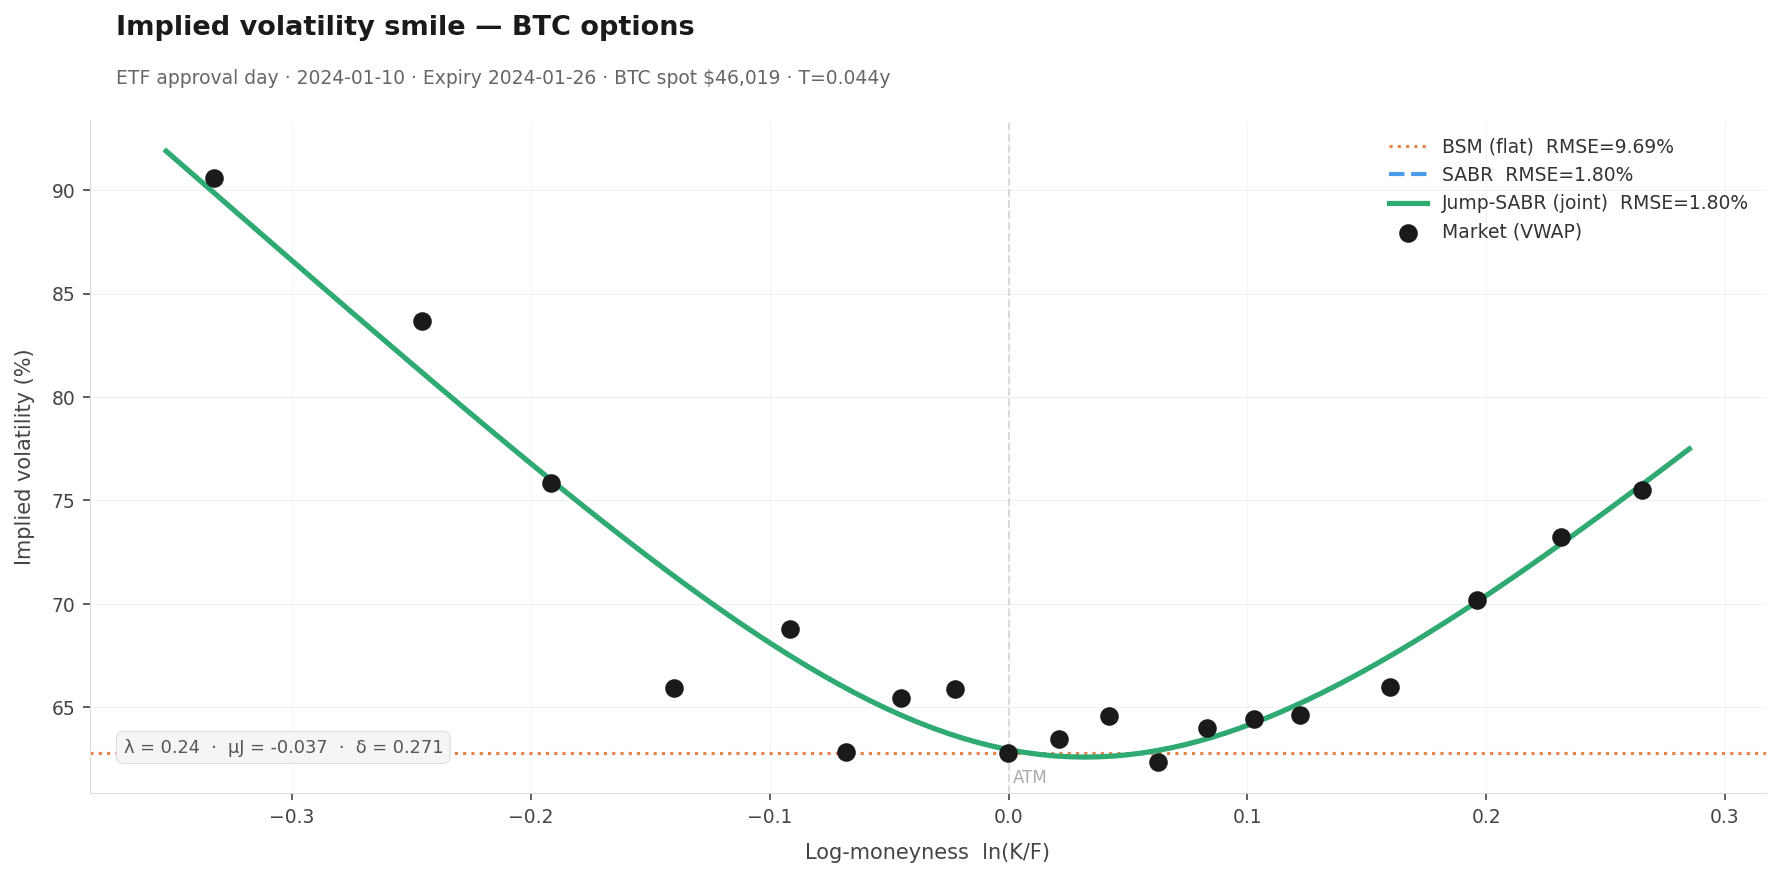

Jump params: λ=0.242, μJ=-0.037, δ=0.271
SABR RMSE: 0.017965 | JS RMSE: 0.017965


In [75]:
# ─────────────────────────────────────────────
# Plot 2 — Smile fit on ETF approval day (redesigned)
# ─────────────────────────────────────────────
target_date   = '2024-01-10'
target_expiry = pd.to_datetime('2024-01-26')

strikes, vols, F, T = get_smile_slice(
    df, target_date, target_expiry, iv_col='mark_iv')

sabr_params, sabr_rmse = calibrate_sabr(F, T, strikes, vols, beta=1.0)
js_params,   js_rmse   = calibrate_jump_sabr_joint(F, T, strikes, vols,
                                                    beta=1.0, n_terms=15)

k_range  = np.linspace(strikes[0]*0.98, strikes[-1]*1.02, 100)
lm_market = np.log(strikes / F)
lm_range  = np.log(k_range / F)

sabr_fit = [hagan_vol(F, K, T,
            sabr_params['alpha'], sabr_params['beta'],
            sabr_params['rho'],   sabr_params['nu'])
            for K in k_range]

js_fit = [jump_sabr_implied_vol(F, K, T, 0,
           js_params['alpha'], js_params['beta'],
           js_params['rho'],   js_params['nu'],
           js_params['lam'],   js_params['mu_J'],
           js_params['delta'], 15)
          for K in k_range]

atm_idx  = np.argmin(np.abs(strikes - F))
bsm_flat = vols[atm_idx]
bsm_rmse_val = bsm_rmse(strikes, vols, F)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

# Plot elements
ax.axhline(bsm_flat*100, color='#E8834C', linestyle=':',
           linewidth=1.5, label=f'BSM (flat)  RMSE={bsm_rmse_val*100:.2f}%',
           zorder=2)
ax.plot(lm_range, [v*100 for v in sabr_fit],
        color='#4C9BE8', linestyle='--', linewidth=2,
        label=f'SABR  RMSE={sabr_rmse*100:.2f}%', zorder=3)
ax.plot(lm_range, [v*100 for v in js_fit],
        color='#2eaa72', linewidth=2.5,
        label=f'Jump-SABR (joint)  RMSE={js_rmse*100:.2f}%', zorder=4)
ax.scatter(lm_market, [v*100 for v in vols],
           color='#1a1a1a', zorder=5, s=55,
           label='Market (VWAP)', linewidths=1.5)

# ATM line
ax.axvline(0, color='#cccccc', linestyle='--', alpha=0.7,
           linewidth=1, zorder=1)
ax.text(0.002, ax.get_ylim()[0] + 0.5, 'ATM',
        fontsize=8, color='#aaaaaa')

# Grid
ax.yaxis.grid(True, color='#000000', alpha=0.06,
              linewidth=0.5, zorder=0)
ax.xaxis.grid(True, color='#000000', alpha=0.04,
              linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Axes
ax.set_xlabel('Log-moneyness  ln(K/F)',
              color='#444444', fontsize=10, labelpad=8)
ax.set_ylabel('Implied volatility (%)',
              color='#444444', fontsize=10, labelpad=8)
ax.tick_params(colors='#444444', labelsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_color('#dddddd')
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# Legend
ax.legend(loc='upper right', framealpha=0,
          labelcolor='#333333', fontsize=9)

# Jump params box
ax.text(0.02, 0.06,
        f'λ = {js_params["lam"]:.2f}  ·  '
        f'μJ = {js_params["mu_J"]:.3f}  ·  '
        f'δ = {js_params["delta"]:.3f}',
        transform=ax.transAxes, fontsize=8.5,
        color='#555555',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#f5f5f5',
                  edgecolor='#dddddd',
                  linewidth=0.5))

# Title
fig.text(0.07, 0.97,
         'Implied volatility smile — BTC options',
         color='#1a1a1a', fontsize=13,
         fontweight='bold', va='top')
fig.text(0.07, 0.91,
         f'ETF approval day · {target_date} · '
         f'Expiry {target_expiry.date()} · '
         f'BTC spot ${F:,.0f} · T={T:.3f}y',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../results/plot2_smile_ETF_day.png',
            dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print(f"Jump params: λ={js_params['lam']:.3f}, "
      f"μJ={js_params['mu_J']:.3f}, δ={js_params['delta']:.3f}")
print(f"SABR RMSE: {sabr_rmse:.6f} | JS RMSE: {js_rmse:.6f}")

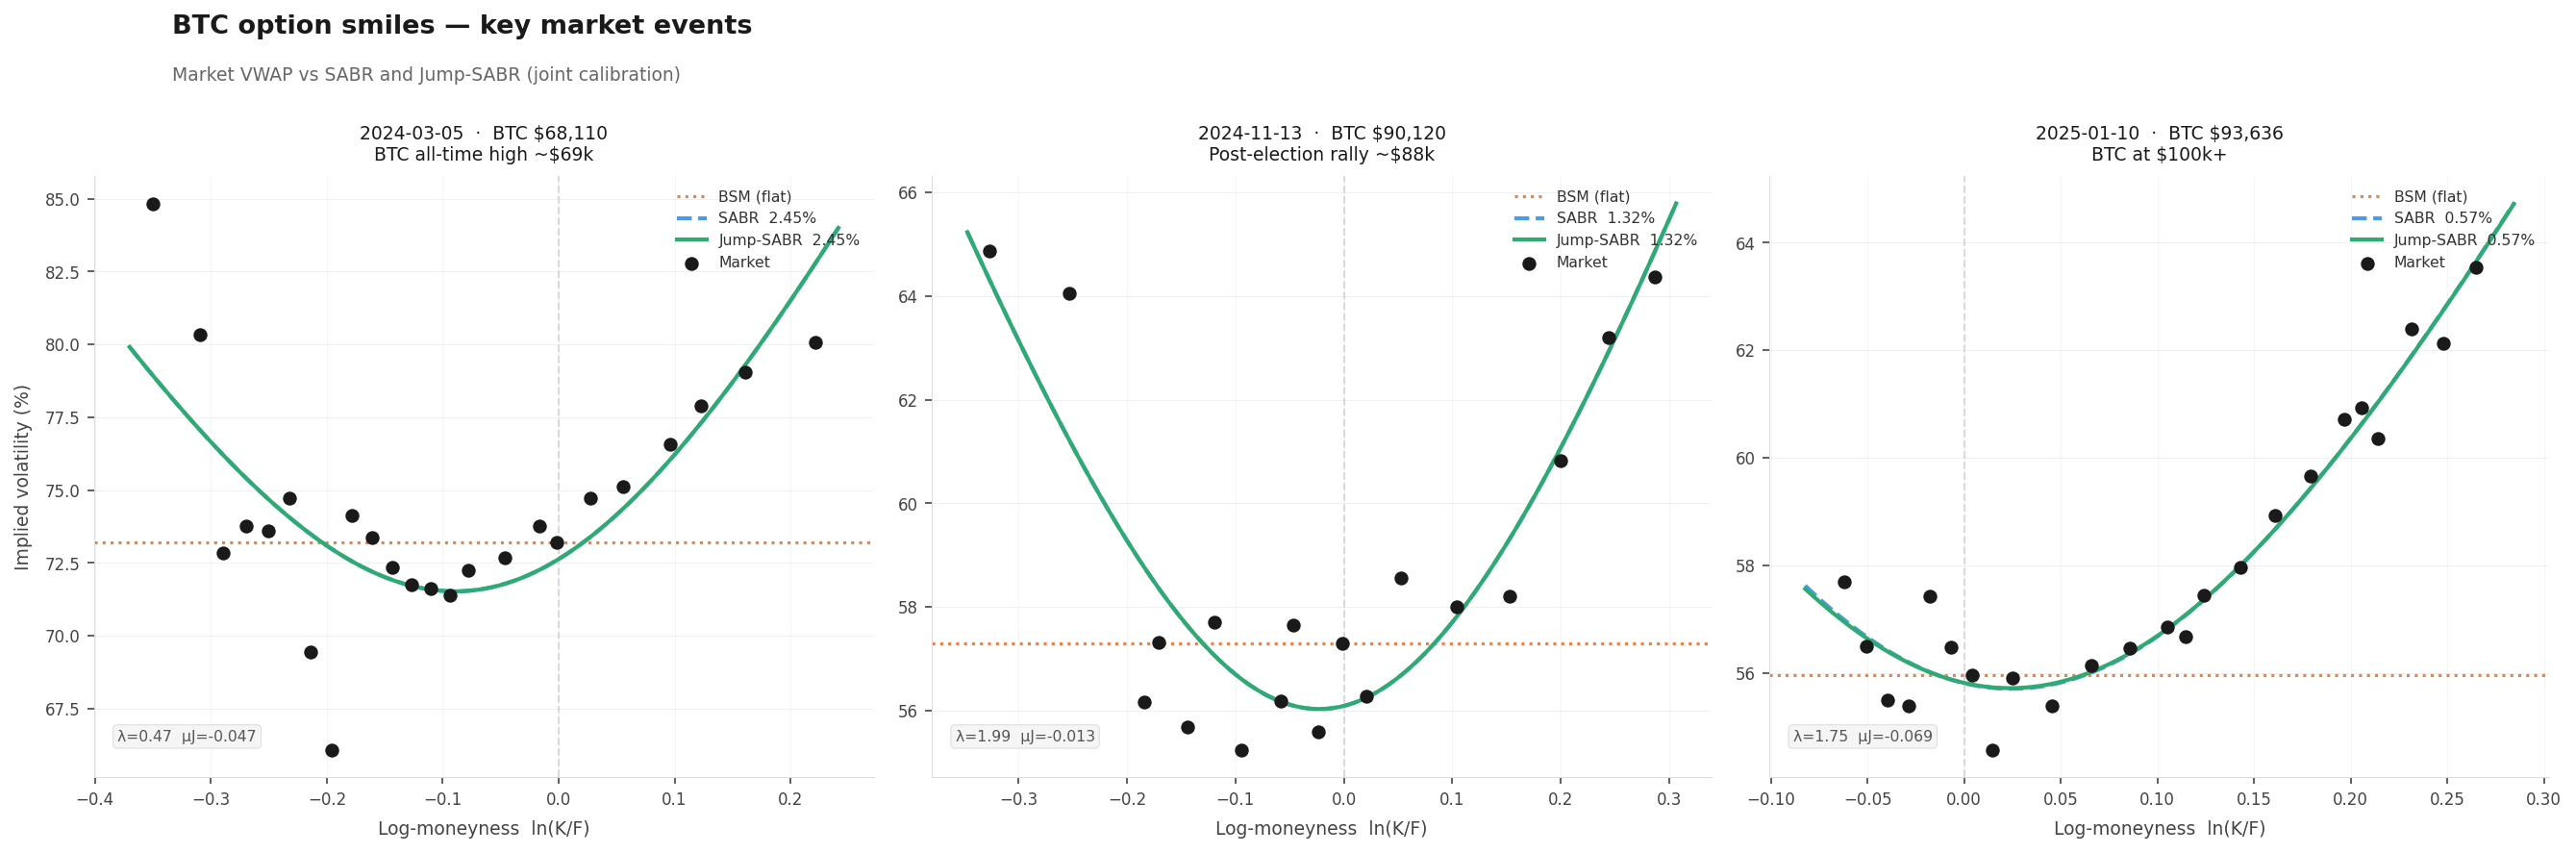

Plot 3 saved


In [56]:
# ─────────────────────────────────────────────
# Plot 3 — Multiple smile plots on key dates (redesigned)
# ─────────────────────────────────────────────
key_dates = [
    ('2024-03-05', pd.to_datetime('2024-03-29'), 'BTC all-time high ~$69k'),
    ('2024-11-13', pd.to_datetime('2024-12-27'), 'Post-election rally ~$88k'),
    ('2025-01-10', pd.to_datetime('2025-01-31'), 'BTC at $100k+'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#ffffff')

for ax, (date, expiry, title) in zip(axes, key_dates):
    try:
        strikes, vols, F, T = get_smile_slice(
            df, date, expiry, iv_col='mark_iv')

        sabr_params, sabr_rmse = calibrate_sabr(
            F, T, strikes, vols, beta=1.0)
        js_params, js_rmse = calibrate_jump_sabr_joint(
            F, T, strikes, vols, beta=1.0, n_terms=15)

        k_range   = np.linspace(strikes[0]*0.98, strikes[-1]*1.02, 100)
        lm_market = np.log(strikes / F)
        lm_range  = np.log(k_range / F)

        sabr_fit = [hagan_vol(F, K, T,
                    sabr_params['alpha'], sabr_params['beta'],
                    sabr_params['rho'],   sabr_params['nu'])
                    for K in k_range]

        js_fit = [jump_sabr_implied_vol(F, K, T, 0,
                   js_params['alpha'], js_params['beta'],
                   js_params['rho'],   js_params['nu'],
                   js_params['lam'],   js_params['mu_J'],
                   js_params['delta'], 15)
                  for K in k_range]

        atm_idx  = np.argmin(np.abs(strikes - F))
        bsm_flat = vols[atm_idx]

        ax.set_facecolor('#ffffff')

        # Plot elements
        ax.axhline(bsm_flat*100, color='#E8834C', linestyle=':',
                   linewidth=1.5, label='BSM (flat)', zorder=2)
        ax.plot(lm_range, [v*100 for v in sabr_fit],
                color='#4C9BE8', linestyle='--', linewidth=2,
                label=f'SABR  {sabr_rmse*100:.2f}%', zorder=3)
        ax.plot(lm_range, [v*100 for v in js_fit],
                color='#2eaa72', linewidth=2,
                label=f'Jump-SABR  {js_rmse*100:.2f}%', zorder=4)
        ax.scatter(lm_market, [v*100 for v in vols],
                   color='#1a1a1a', zorder=5, s=35, label='Market')

        # ATM line
        ax.axvline(0, color='#cccccc', linestyle='--',
                   alpha=0.7, linewidth=1, zorder=1)

        # Grid
        ax.yaxis.grid(True, color='#000000', alpha=0.06,
                      linewidth=0.5, zorder=0)
        ax.xaxis.grid(True, color='#000000', alpha=0.04,
                      linewidth=0.5, zorder=0)
        ax.set_axisbelow(True)

        # Spines
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_color('#dddddd')
        ax.spines['left'].set_color('#dddddd')
        ax.spines['bottom'].set_linewidth(0.5)
        ax.spines['left'].set_linewidth(0.5)

        # Axes labels
        ax.set_xlabel('Log-moneyness  ln(K/F)',
                      color='#444444', fontsize=9, labelpad=6)
        if ax == axes[0]:
            ax.set_ylabel('Implied volatility (%)',
                          color='#444444', fontsize=9, labelpad=6)
        ax.tick_params(colors='#444444', labelsize=8)

        # Legend
        ax.legend(fontsize=7.5, framealpha=0,
                  labelcolor='#333333', loc='upper right')

        # Jump params annotation
        ax.text(0.03, 0.06,
                f'λ={js_params["lam"]:.2f}  μJ={js_params["mu_J"]:.3f}',
                transform=ax.transAxes, fontsize=7.5,
                color='#555555',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='#f5f5f5',
                          edgecolor='#dddddd',
                          linewidth=0.5))

        # Panel title
        ax.set_title(f'{date}  ·  BTC ${F:,.0f}\n{title}',
                     fontsize=9, color='#1a1a1a', pad=8)

    except Exception as e:
        ax.set_title(f'{date}\nError: {str(e)[:50]}')
        print(f"Error on {date}: {e}")

fig.text(0.07, 0.98,
         'BTC option smiles — key market events',
         color='#1a1a1a', fontsize=13,
         fontweight='bold', va='top')
fig.text(0.07, 0.92,
         'Market VWAP vs SABR and Jump-SABR (joint calibration)',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../results/plot3_key_smiles.png',
            dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print("Plot 3 saved")

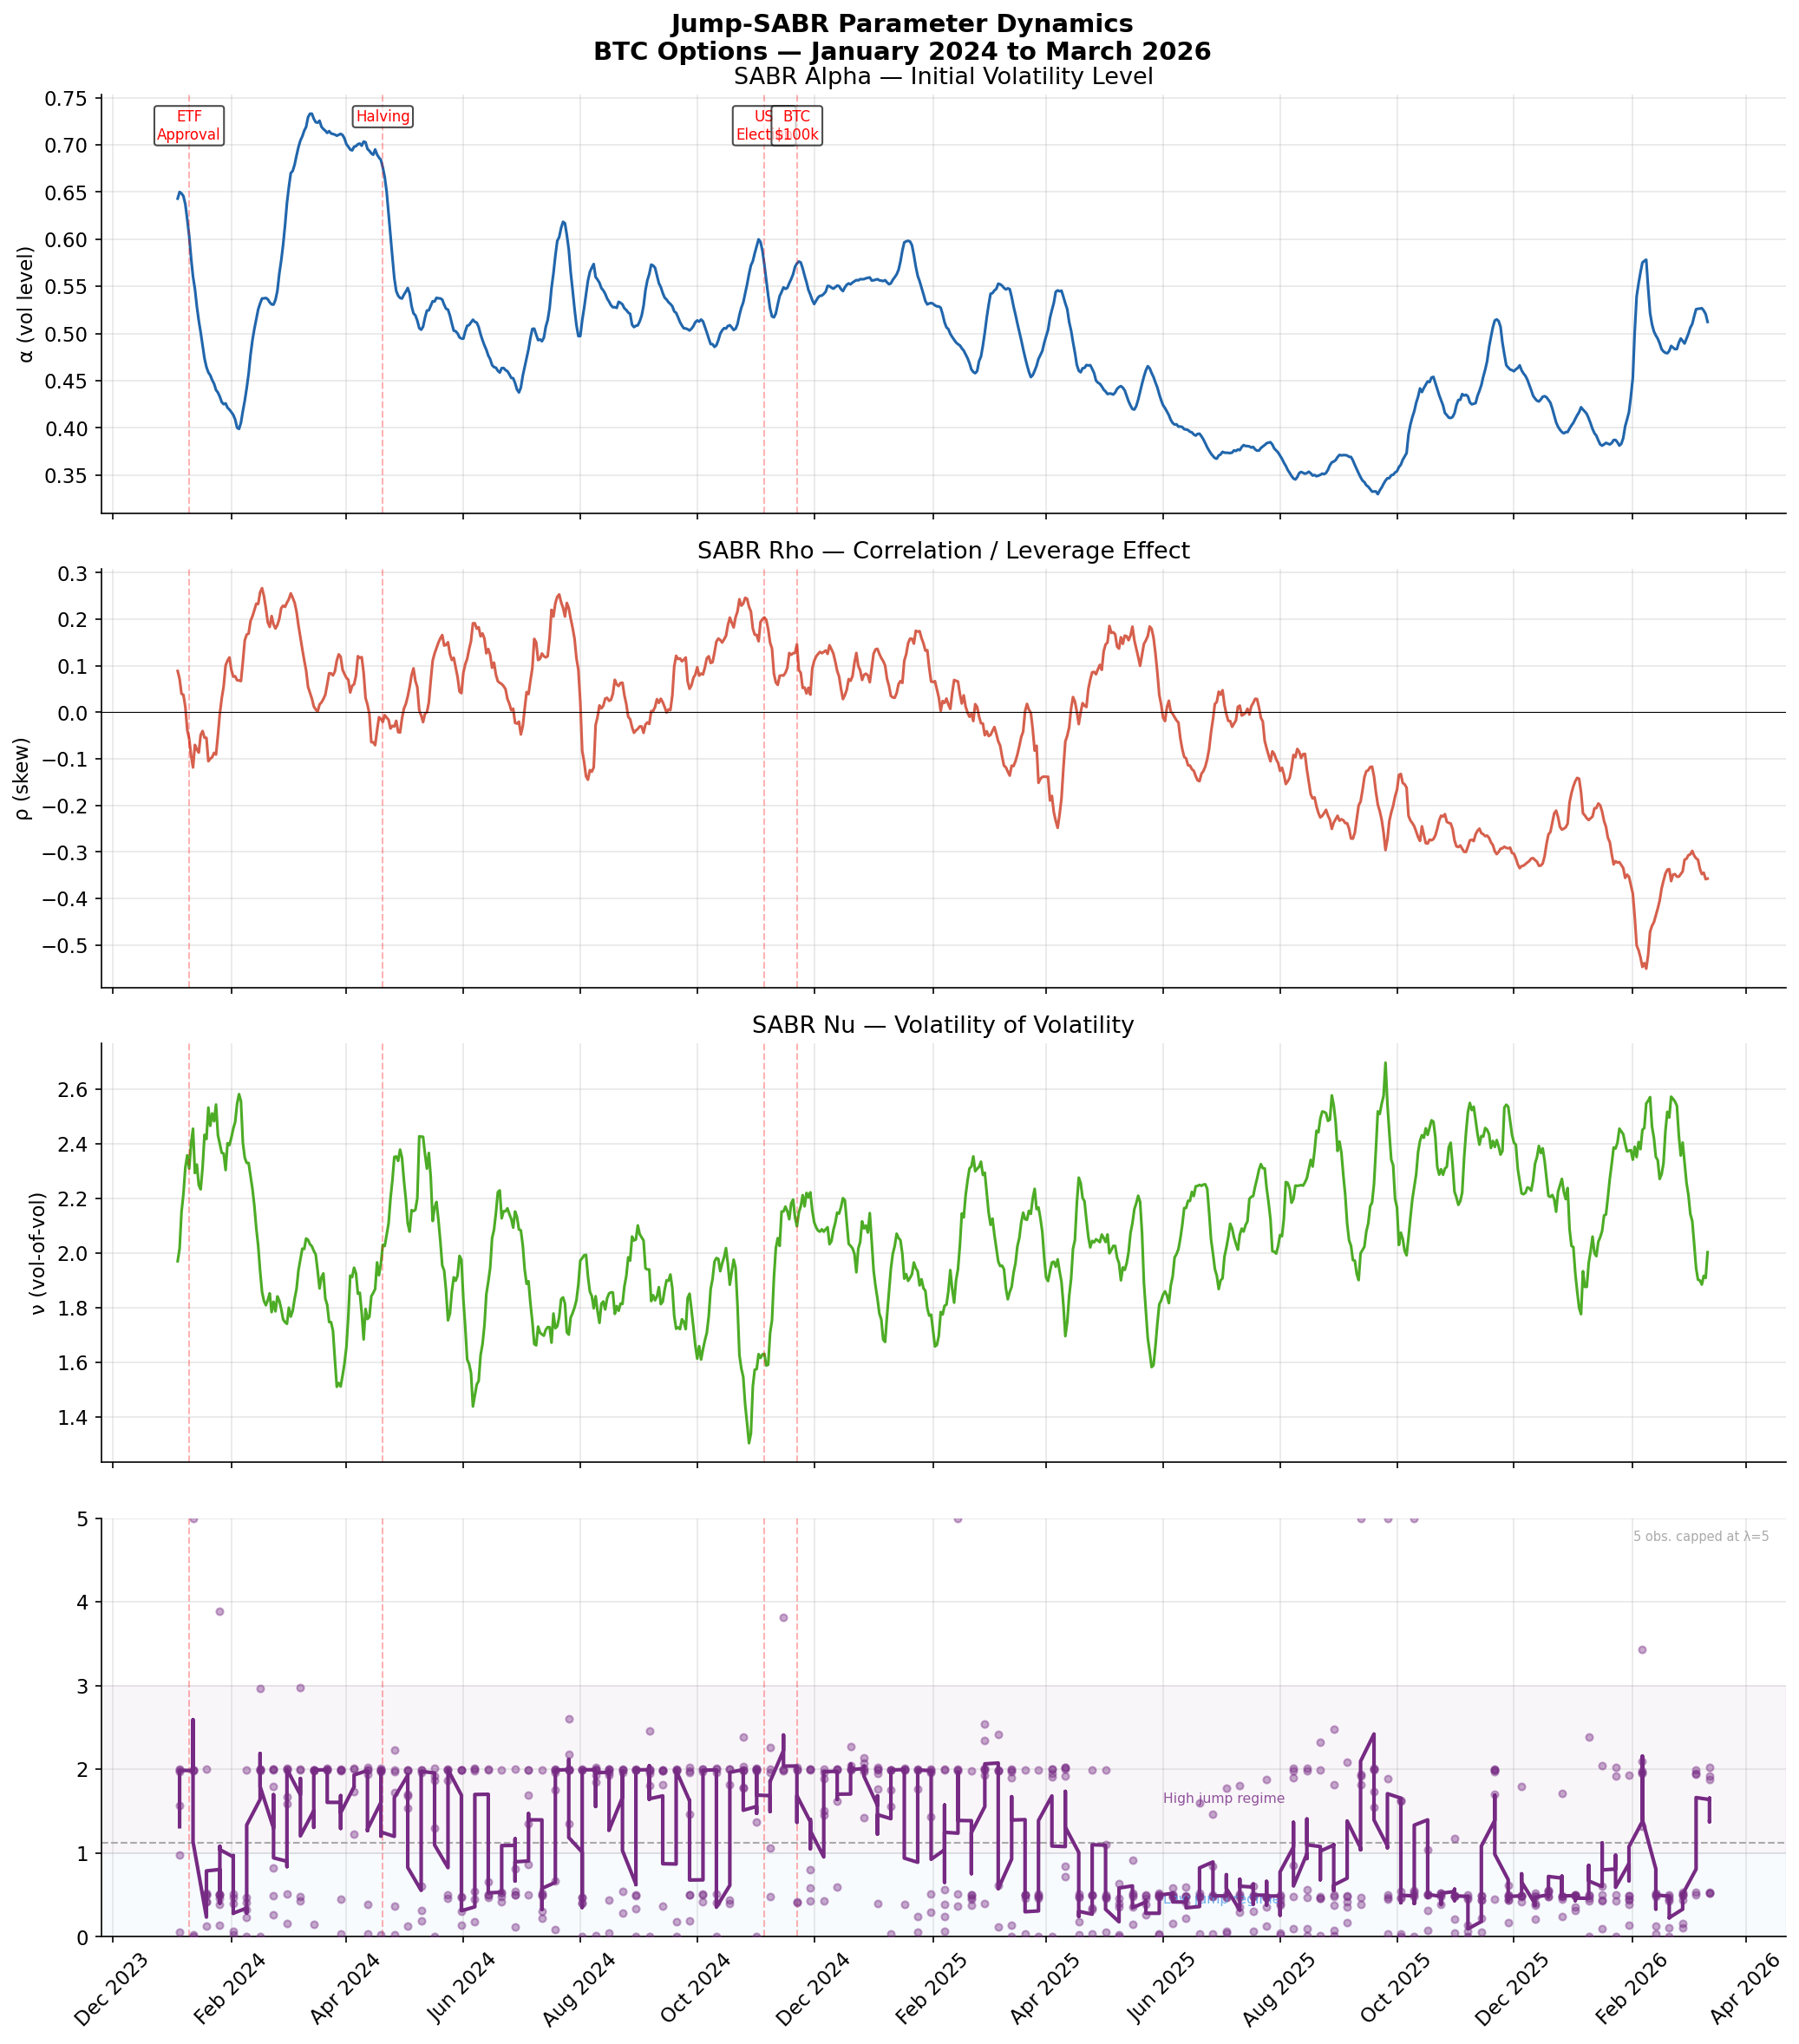

Plot 4 revised and saved


In [66]:
# ─────────────────────────────────────────────
# Plot 4 revised — remove sequential lambda
# replace with joint calibration lambda
# ─────────────────────────────────────────────

df_seq   = pd.read_csv('../data/calibration_results.csv')
df_joint = pd.read_csv('../data/joint_calibration_full.csv')

df_seq['date']   = pd.to_datetime(df_seq['date'])
df_joint['date'] = pd.to_datetime(df_joint['date'])

# Daily averages from sequential
daily = df_seq.groupby('date').agg(
    sabr_alpha = ('sabr_alpha', 'mean'),
    sabr_rho   = ('sabr_rho',   'mean'),
    sabr_nu    = ('sabr_nu',    'mean'),
).reset_index()

for col in ['sabr_alpha', 'sabr_rho', 'sabr_nu']:
    daily[f'{col}_smooth'] = daily[col].rolling(7, center=True).mean()

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

events = {
    '2024-01-10': 'ETF\nApproval',
    '2024-04-20': 'Halving',
    '2024-11-05': 'US\nElection',
    '2024-11-22': 'BTC\n$100k',
}

# Panel 1 — Alpha
axes[0].plot(daily['date'], daily['sabr_alpha_smooth'],
             color='#2166ac', linewidth=1.5)
axes[0].set_ylabel('α (vol level)')
axes[0].set_title('SABR Alpha — Initial Volatility Level')

# Panel 2 — Rho
axes[1].plot(daily['date'], daily['sabr_rho_smooth'],
             color='#d6604d', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('ρ (skew)')
axes[1].set_title('SABR Rho — Correlation / Leverage Effect')

# Panel 3 — Nu
axes[2].plot(daily['date'], daily['sabr_nu_smooth'],
             color='#4dac26', linewidth=1.5)
axes[2].set_ylabel('ν (vol-of-vol)')
axes[2].set_title('SABR Nu — Volatility of Volatility')

# Panel 4 — Lambda (capped at 5 for readability)
ax4 = axes[3]
ax4.set_facecolor('#ffffff')

# Cap extreme outliers for display
lam_display = df_joint['js_lam'].clip(upper=5)
lam_smooth  = lam_display.rolling(5, center=True).mean()

ax4.scatter(df_joint['date'], lam_display,
            color='#762a83', s=15, alpha=0.4, zorder=3,
            label='Weekly observation')
ax4.plot(df_joint['date'], lam_smooth,
         color='#762a83', linewidth=2,
         label='5-week moving avg', zorder=4)
ax4.axhline(df_joint['js_lam'].mean(), color='#aaaaaa',
            linestyle='--', linewidth=1,
            label=f"Mean λ = {df_joint['js_lam'].mean():.2f}")

# Shade two regimes
ax4.axhspan(0, 1, alpha=0.04, color='#4C9BE8', zorder=0)
ax4.axhspan(1, 3, alpha=0.04, color='#762a83', zorder=0)

ax4.set_ylim(0, 5)
ax4.text(pd.to_datetime('2025-06-01'), 0.4,
         'Low jump regime', fontsize=7.5, color='#4C9BE8', alpha=0.8)
ax4.text(pd.to_datetime('2025-06-01'), 1.6,
         'High jump regime', fontsize=7.5, color='#762a83', alpha=0.8)

# Note about capped values
n_capped = (df_joint['js_lam'] > 5).sum()
ax4.text(0.99, 0.97, f'{n_capped} obs. capped at λ=5',
         transform=ax4.transAxes, fontsize=7,
         color='#aaaaaa', ha='right', va='top')

# Event lines and labels
for ax in axes:
    for date in events:
        ax.axvline(pd.to_datetime(date), color='red',
                  alpha=0.3, linestyle='--', linewidth=1)

ylim = axes[0].get_ylim()
for date, label in events.items():
    axes[0].text(pd.to_datetime(date), ylim[1]*0.98,
                label, fontsize=8, color='red',
                ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.2',
                         facecolor='white', alpha=0.7))

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('Jump-SABR Parameter Dynamics\nBTC Options — January 2024 to March 2026',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plot4_parameter_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 revised and saved")

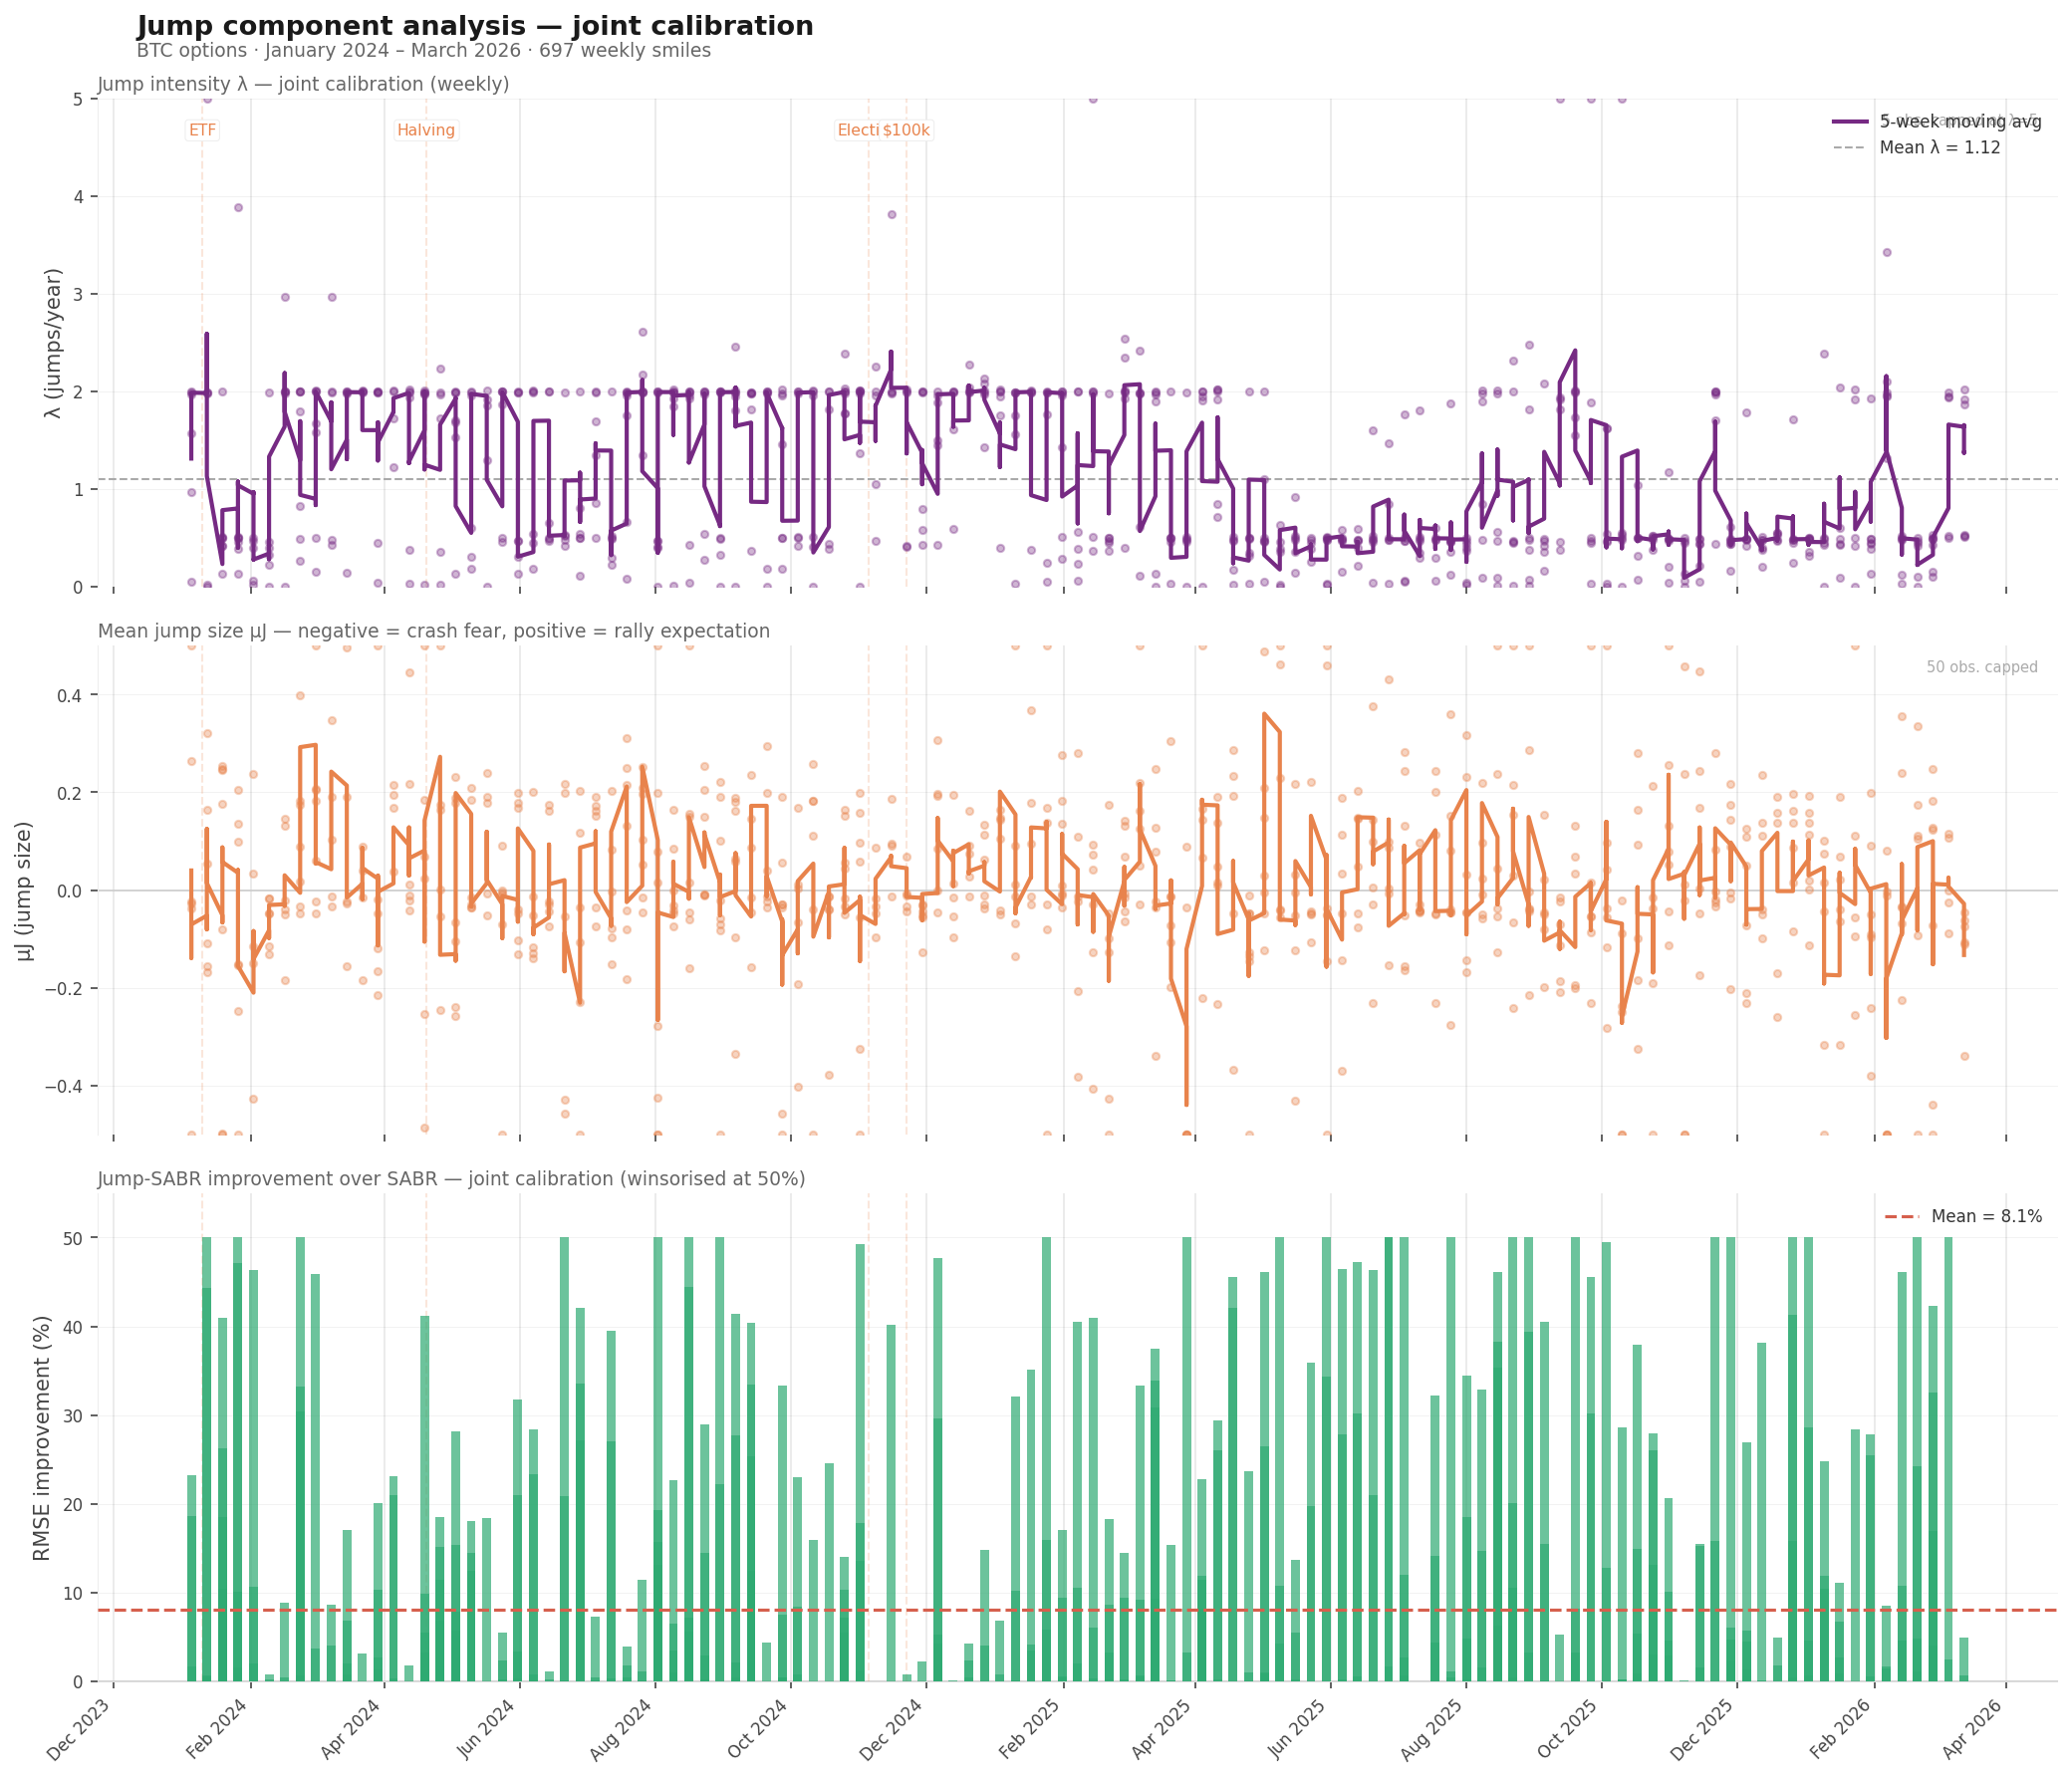

Plot 5 saved
Mean improvement (winsorised): 8.08%


In [68]:
# ─────────────────────────────────────────────
# Plot 5 — Jump analysis (redesigned, full dataset)
# ─────────────────────────────────────────────
df_joint = pd.read_csv('../data/joint_calibration_full.csv')
df_joint['date'] = pd.to_datetime(df_joint['date'])
df_joint = df_joint.dropna(subset=['js_rmse'])

# Cap outliers for display
df_joint['lam_display']  = df_joint['js_lam'].clip(upper=5)
df_joint['muJ_display']  = df_joint['js_muJ'].clip(lower=-0.5, upper=0.5)
df_joint['imp_display']  = df_joint['improvement'].clip(upper=50, lower=0)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.patch.set_facecolor('#ffffff')

events = {
    '2024-01-10': 'ETF',
    '2024-04-20': 'Halving',
    '2024-11-05': 'Election',
    '2024-11-22': '$100k',
}

# ── Panel 1 — Lambda ──
ax = axes[0]
ax.set_facecolor('#ffffff')

lam_smooth = df_joint.set_index('date')['lam_display']\
                      .rolling(5, center=True).mean()

ax.scatter(df_joint['date'], df_joint['lam_display'],
           color='#762a83', s=12, alpha=0.35, zorder=3)
ax.plot(lam_smooth.index, lam_smooth.values,
        color='#762a83', linewidth=2, zorder=4,
        label='5-week moving avg')
ax.axhline(df_joint['js_lam'].clip(upper=5).mean(),
           color='#aaaaaa', linestyle='--', linewidth=1,
           label=f"Mean λ = {df_joint['js_lam'].mean():.2f}")
ax.set_ylim(0, 5)
ax.set_ylabel('λ (jumps/year)', color='#444444', fontsize=10)
ax.set_title('Jump intensity λ — joint calibration (weekly)',
             fontsize=9, color='#666666', loc='left', pad=4)
ax.legend(fontsize=8, framealpha=0, labelcolor='#333333',
          loc='upper right')
n_capped = (df_joint['js_lam'] > 5).sum()
ax.text(0.99, 0.97, f'{n_capped} obs. capped at λ=5',
        transform=ax.transAxes, fontsize=7,
        color='#aaaaaa', ha='right', va='top')

# ── Panel 2 — Mu_J ──
ax = axes[1]
ax.set_facecolor('#ffffff')

muJ_smooth = df_joint.set_index('date')['muJ_display']\
                      .rolling(5, center=True).mean()

ax.scatter(df_joint['date'], df_joint['muJ_display'],
           color='#E8834C', s=12, alpha=0.35, zorder=3)
ax.plot(muJ_smooth.index, muJ_smooth.values,
        color='#E8834C', linewidth=2, zorder=4)
ax.axhline(0, color='#cccccc', linewidth=0.8, zorder=2)
ax.set_ylim(-0.5, 0.5)
ax.set_ylabel('μJ (jump size)', color='#444444', fontsize=10)
ax.set_title('Mean jump size μJ — negative = crash fear, positive = rally expectation',
             fontsize=9, color='#666666', loc='left', pad=4)
n_capped2 = ((df_joint['js_muJ'] < -0.5) | (df_joint['js_muJ'] > 0.5)).sum()
ax.text(0.99, 0.97, f'{n_capped2} obs. capped',
        transform=ax.transAxes, fontsize=7,
        color='#aaaaaa', ha='right', va='top')

# ── Panel 3 — RMSE improvement ──
ax = axes[2]
ax.set_facecolor('#ffffff')

mean_imp = df_joint['imp_display'].mean()
ax.bar(df_joint['date'], df_joint['imp_display'],
       color='#2eaa72', alpha=0.7, width=4, zorder=3)
ax.axhline(mean_imp, color='#d6604d', linestyle='--',
           linewidth=1.5, zorder=4,
           label=f'Mean = {mean_imp:.1f}%')
ax.axhline(0, color='#cccccc', linewidth=0.8, zorder=2)
ax.set_ylim(0, 55)
ax.set_ylabel('RMSE improvement (%)', color='#444444', fontsize=10)
ax.set_title('Jump-SABR improvement over SABR — joint calibration (winsorised at 50%)',
             fontsize=9, color='#666666', loc='left', pad=4)
ax.legend(fontsize=8, framealpha=0, labelcolor='#333333',
          loc='upper right')

# Event lines and labels on all panels
for ax in axes:
    ax.yaxis.grid(True, color='#000000', alpha=0.05,
                  linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors='#444444', labelsize=8)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_color('#eeeeee')
    ax.spines['left'].set_linewidth(0.5)
    for date in events:
        ax.axvline(pd.to_datetime(date), color='#E8834C',
                  alpha=0.2, linestyle='--', linewidth=1)

# Event labels on top panel only
ylim = axes[0].get_ylim()
for date, label in events.items():
    axes[0].text(pd.to_datetime(date), ylim[1]*0.95,
                label, fontsize=7.5, color='#E8834C',
                ha='center', va='top',
                bbox=dict(boxstyle='round,pad=0.2',
                         facecolor='white',
                         edgecolor='#eeeeee',
                         linewidth=0.5))

axes[2].spines['bottom'].set_visible(True)
axes[2].spines['bottom'].set_color('#dddddd')
axes[2].spines['bottom'].set_linewidth(0.5)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right', fontsize=8, color='#444444')

fig.text(0.07, 0.99,
         'Jump component analysis — joint calibration',
         color='#1a1a1a', fontsize=13,
         fontweight='bold', va='top')
fig.text(0.07, 0.975,
         'BTC options · January 2024 – March 2026 · 697 weekly smiles',
         color='#666666', fontsize=9, va='top')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../results/plot5_jump_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print("Plot 5 saved")
print(f"Mean improvement (winsorised): {mean_imp:.2f}%")

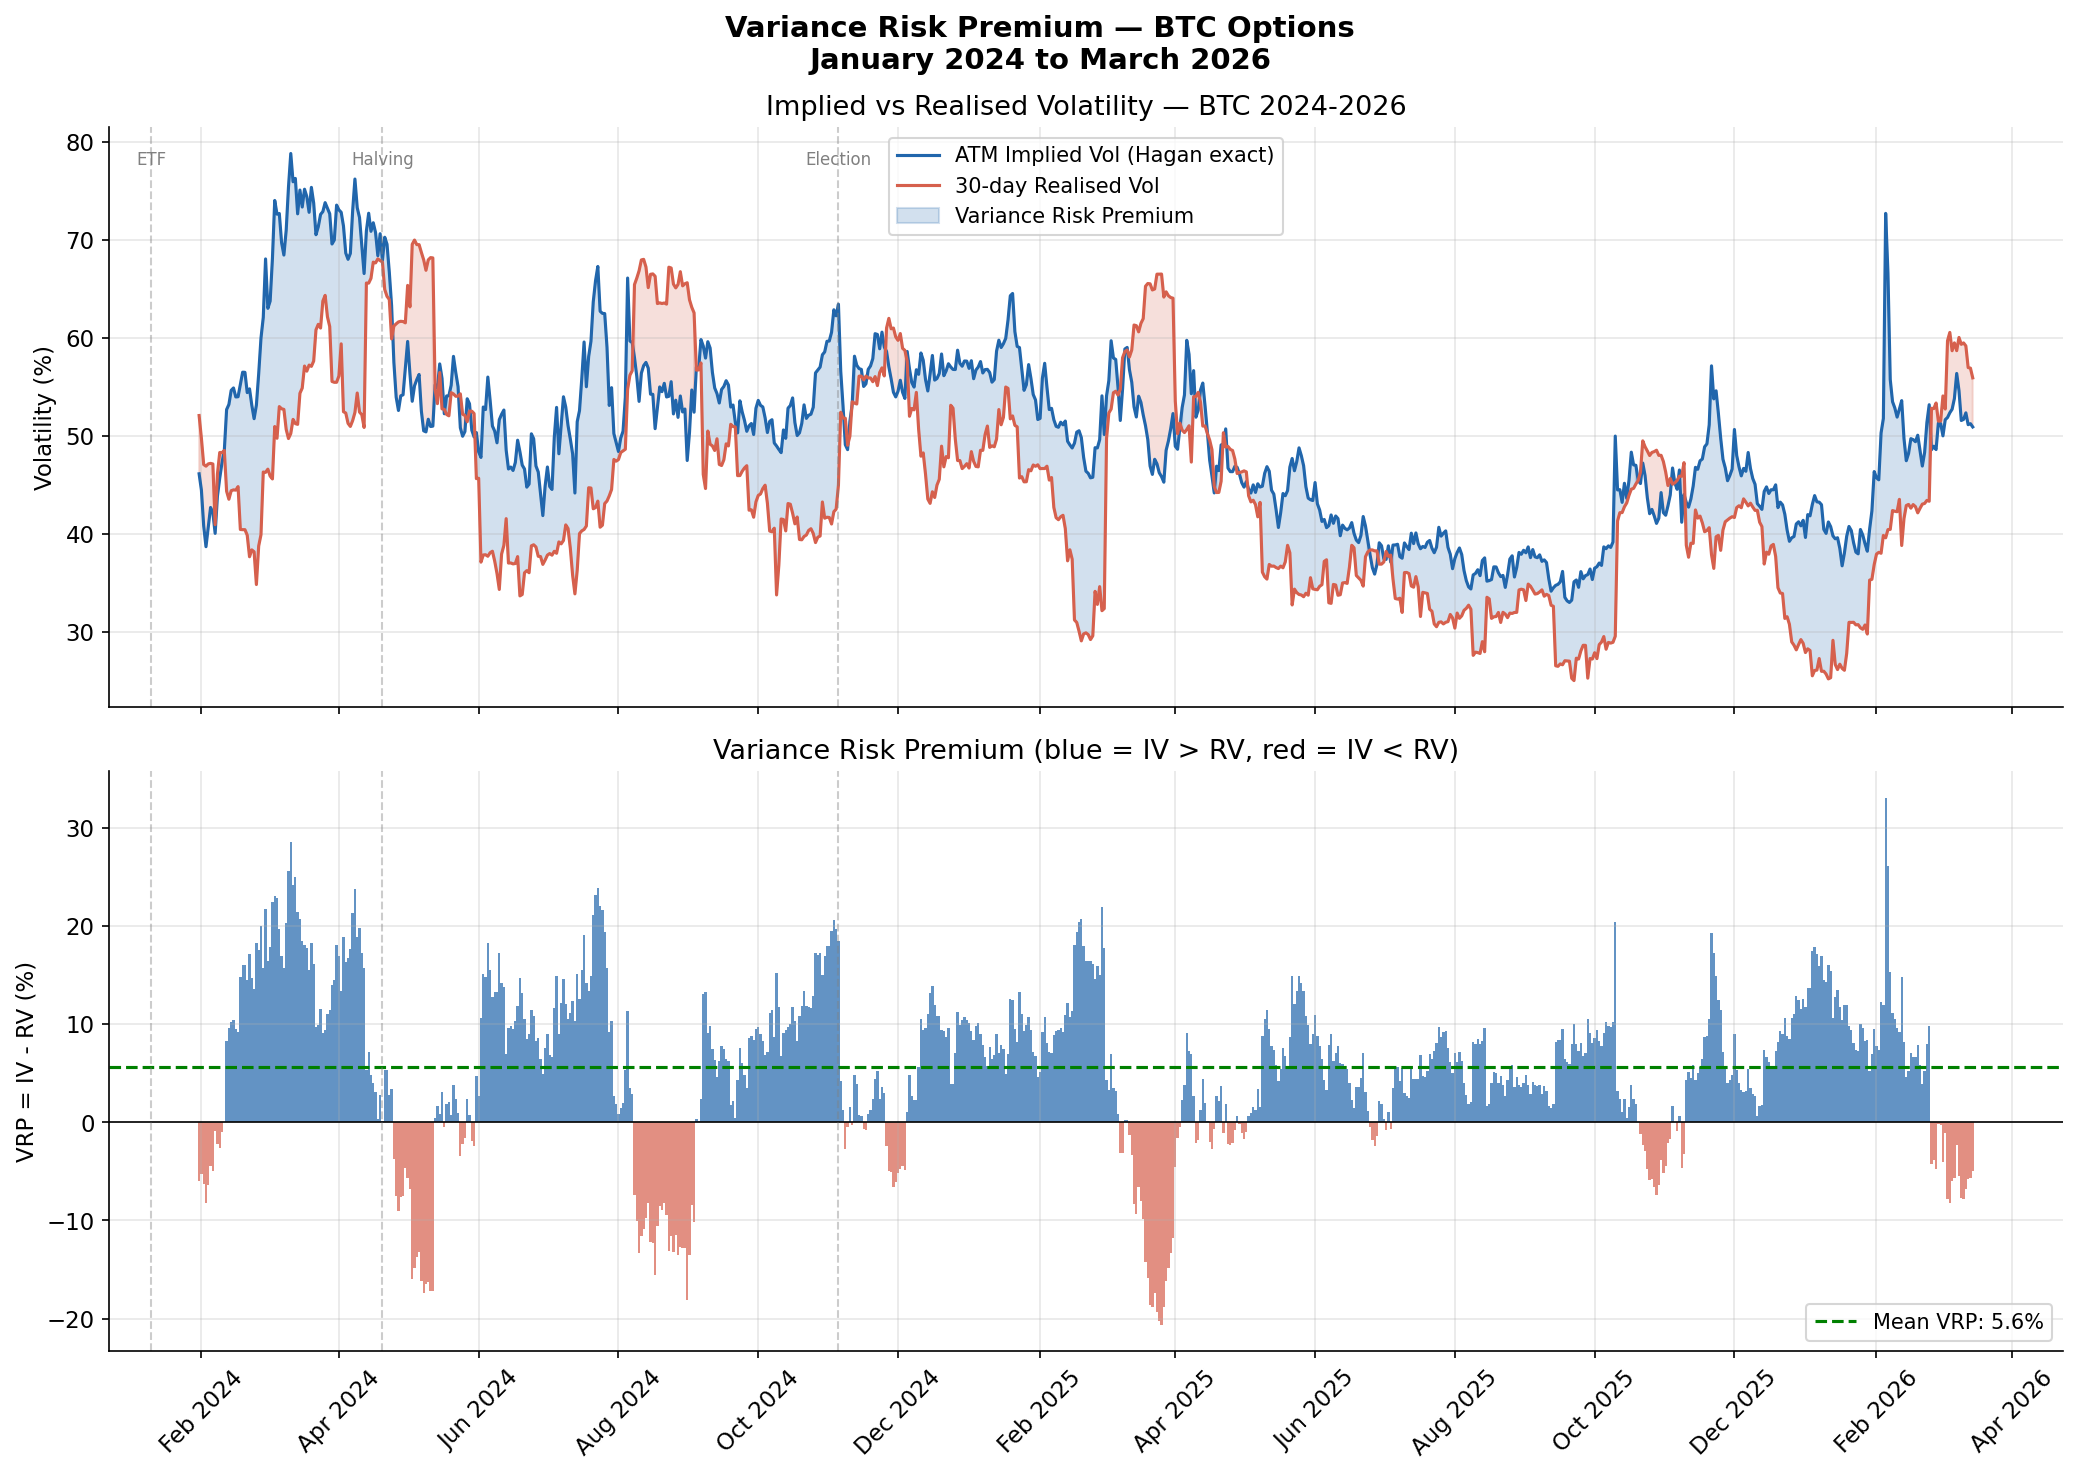

Mean VRP: 5.63%
% days IV > RV: 79.5%
Max IV: 78.8%
Max RV: 70.0%


In [44]:
# ─────────────────────────────────────────────
# Plot 6 — Implied vol vs Realised vol
# Variance Risk Premium
# ─────────────────────────────────────────────

# Get daily ATM implied vol from sequential calibration
df_seq = pd.read_csv('../data/calibration_results.csv')
df_seq['date'] = pd.to_datetime(df_seq['date'])

# Corrected ATM IV using exact Hagan formula (beta=1)
df_seq['atm_iv_exact'] = df_seq['sabr_alpha'] * (
    1 + (
        (2 - 3 * df_seq['sabr_rho']**2) / 24 * df_seq['sabr_nu']**2
        + df_seq['sabr_rho'] * df_seq['sabr_nu'] * df_seq['sabr_alpha'] / 4
    ) * df_seq['T']
)
daily_iv = df_seq.groupby('date')['atm_iv_exact'].mean().reset_index()
daily_iv.columns = ['date', 'atm_iv']

# Get BTC spot prices from our smile data
df_smile = pd.read_csv('../data/btc_daily_smile.csv')
df_smile['date'] = pd.to_datetime(df_smile['date'])
spot = df_smile.groupby('date')['index_price'].last().reset_index()
spot.columns = ['date', 'spot']

# Compute realised vol — 30-day rolling
spot = spot.sort_values('date')
spot['log_return'] = np.log(spot['spot'] / spot['spot'].shift(1))
spot['realised_vol_30d'] = spot['log_return'].rolling(30).std() * np.sqrt(365)

# Merge
df_vrp = daily_iv.merge(spot[['date','spot','realised_vol_30d']], 
                         on='date', how='inner')
df_vrp = df_vrp.dropna()

# Variance Risk Premium = IV - Realised Vol
df_vrp['vrp'] = df_vrp['atm_iv'] - df_vrp['realised_vol_30d']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1 — IV vs Realised Vol
axes[0].plot(df_vrp['date'], df_vrp['atm_iv']*100,
             color='#2166ac', linewidth=1.5, label='ATM Implied Vol (Hagan exact)')
axes[0].plot(df_vrp['date'], df_vrp['realised_vol_30d']*100,
             color='#d6604d', linewidth=1.5, label='30-day Realised Vol')
axes[0].fill_between(df_vrp['date'],
                      df_vrp['atm_iv']*100,
                      df_vrp['realised_vol_30d']*100,
                      where=df_vrp['atm_iv'] > df_vrp['realised_vol_30d'],
                      alpha=0.2, color='#2166ac', label='Variance Risk Premium')
axes[0].fill_between(df_vrp['date'],
                      df_vrp['atm_iv']*100,
                      df_vrp['realised_vol_30d']*100,
                      where=df_vrp['atm_iv'] <= df_vrp['realised_vol_30d'],
                      alpha=0.2, color='#d6604d')
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Implied vs Realised Volatility — BTC 2024-2026')
axes[0].legend()

# Panel 2 — VRP
axes[1].bar(df_vrp['date'], df_vrp['vrp']*100,
            color=np.where(df_vrp['vrp'] > 0, '#2166ac', '#d6604d'),
            alpha=0.7, width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(df_vrp['vrp'].mean()*100, color='green',
                linestyle='--', linewidth=1.5,
                label=f'Mean VRP: {df_vrp["vrp"].mean()*100:.1f}%')
axes[1].set_ylabel('VRP = IV - RV (%)')
axes[1].set_title('Variance Risk Premium (blue = IV > RV, red = IV < RV)')
axes[1].legend()

# Event lines
events = {
    '2024-01-10': 'ETF',
    '2024-04-20': 'Halving',
    '2024-11-05': 'Election',
}
for ax in axes:
    for date, label in events.items():
        ax.axvline(pd.to_datetime(date), color='grey',
                  alpha=0.4, linestyle='--', linewidth=1)

ylim = axes[0].get_ylim()
for date, label in events.items():
    axes[0].text(pd.to_datetime(date), ylim[1]*0.97,
                label, fontsize=8, color='grey',
                ha='center', va='top')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('Variance Risk Premium — BTC Options\nJanuary 2024 to March 2026',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plot6_variance_risk_premium.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean VRP: {df_vrp['vrp'].mean()*100:.2f}%")
print(f"% days IV > RV: {(df_vrp['vrp'] > 0).mean()*100:.1f}%")
print(f"Max IV: {df_vrp['atm_iv'].max()*100:.1f}%")
print(f"Max RV: {df_vrp['realised_vol_30d'].max()*100:.1f}%")

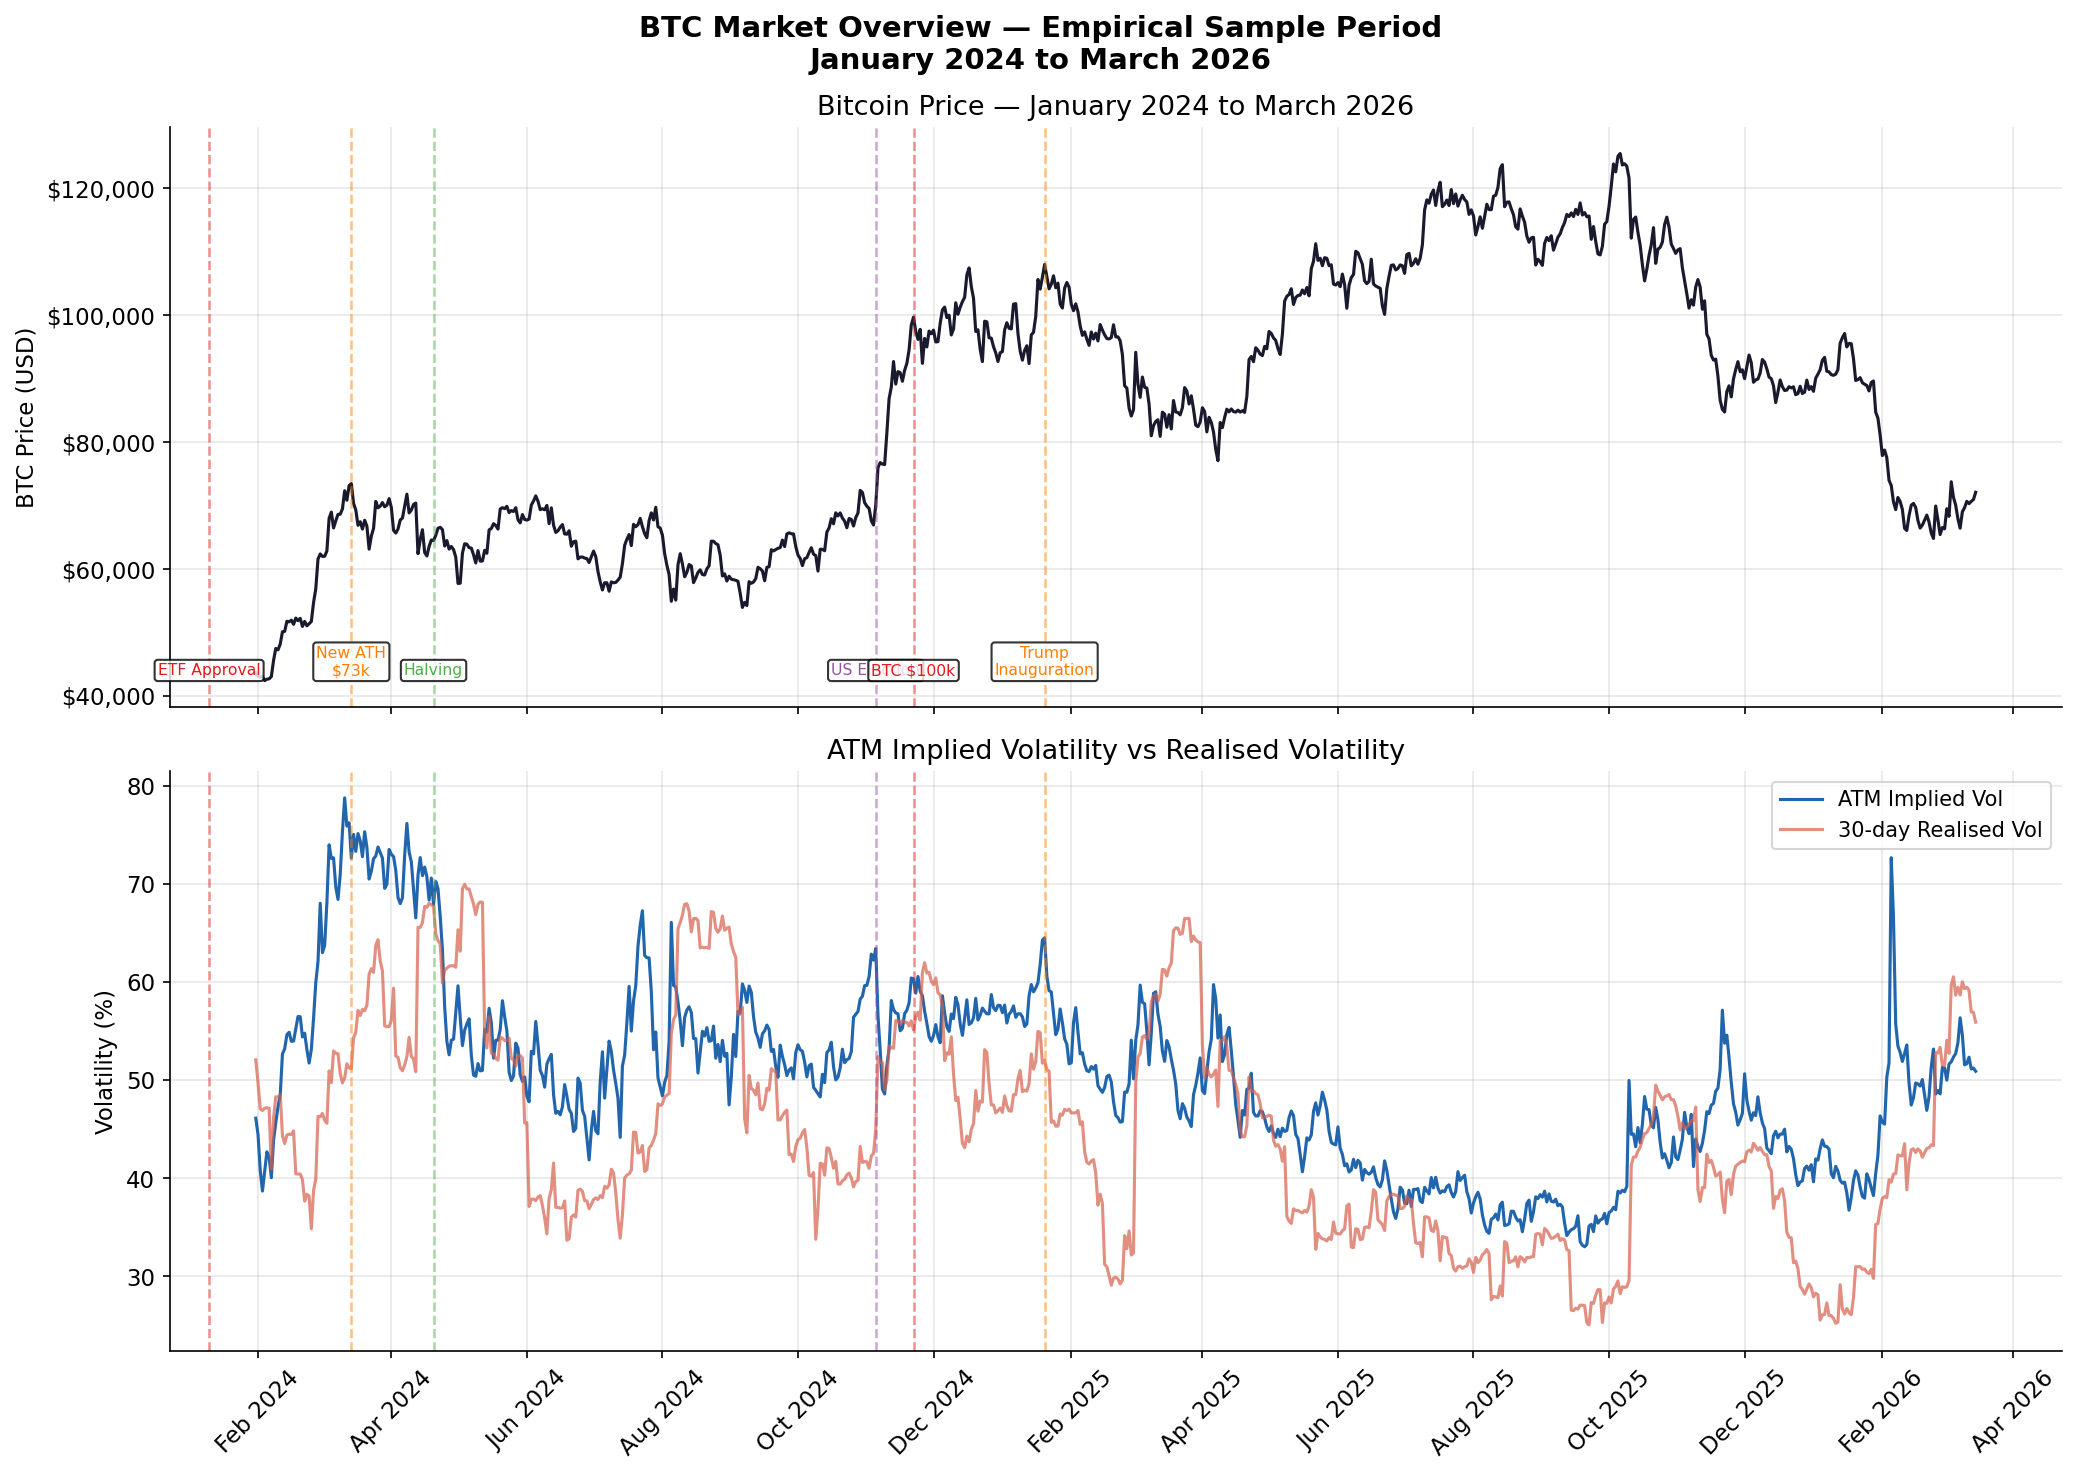

Plot 7 saved


In [45]:
# ─────────────────────────────────────────────
# Plot 7 — BTC price with key events
# Context plot for thesis
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1 — BTC price
axes[0].plot(df_vrp['date'], df_vrp['spot'],
             color='#1a1a2e', linewidth=1.5)
axes[0].set_ylabel('BTC Price (USD)')
axes[0].set_title('Bitcoin Price — January 2024 to March 2026')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Panel 2 — ATM implied vol
axes[1].plot(df_vrp['date'], df_vrp['atm_iv']*100,
             color='#2166ac', linewidth=1.5, label='ATM Implied Vol')
axes[1].plot(df_vrp['date'], df_vrp['realised_vol_30d']*100,
             color='#d6604d', linewidth=1.5, alpha=0.7,
             label='30-day Realised Vol')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('ATM Implied Volatility vs Realised Volatility')
axes[1].legend()

# Key events
events_full = {
    '2024-01-10': ('ETF Approval', '#e41a1c'),
    '2024-03-14': ('New ATH\n$73k', '#ff7f00'),
    '2024-04-20': ('Halving', '#4daf4a'),
    '2024-11-05': ('US Election', '#984ea3'),
    '2024-11-22': ('BTC $100k', '#e41a1c'),
    '2025-01-20': ('Trump\nInauguration', '#ff7f00'),
}

for ax in axes:
    for date, (label, color) in events_full.items():
        ax.axvline(pd.to_datetime(date), color=color,
                  alpha=0.5, linestyle='--', linewidth=1.2)

# Labels on price panel
ylim = axes[0].get_ylim()
for date, (label, color) in events_full.items():
    axes[0].text(pd.to_datetime(date),
                ylim[0] + (ylim[1]-ylim[0])*0.05,
                label, fontsize=7.5, color=color,
                ha='center', va='bottom', rotation=0,
                bbox=dict(boxstyle='round,pad=0.2',
                         facecolor='white', alpha=0.8))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('BTC Market Overview — Empirical Sample Period\nJanuary 2024 to March 2026',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plot7_btc_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 saved")

In [76]:
print("=== THESIS KEY NUMBERS ===\n")

print("--- Dataset ---")
df_smile = pd.read_csv('../data/btc_daily_smile.csv')
print(f"Total trades:        2,636,099")
print(f"Daily smile obs:     {len(df_smile):,}")
print(f"Trading days:        {df_smile['date'].nunique()}")
print(f"Date range:          2024-01-01 to 2026-03-15")
print(f"Strike range:        ${df_smile['strike'].min():,.0f} to ${df_smile['strike'].max():,.0f}")
print(f"IV range:            {df_smile['mark_iv'].min():.1%} to {df_smile['mark_iv'].max():.1%}")

print("\n--- Calibration sample ---")
print(f"Sequential smiles:   4,339 (daily, all maturities)")
print(f"Joint smiles:        697 (weekly, all maturities)")
print(f"Joint failure rate:  2.9% (21 smiles)")
print(f"Maturity range:      7 to 180 days")

print("\n--- Main results ---")
df_jf = pd.read_csv('../data/joint_calibration_full.csv').dropna(subset=['js_rmse'])
print(f"SABR mean RMSE:      {df_jf['sabr_rmse'].mean()*100:.4f}%")
print(f"Jump-SABR mean RMSE: {df_jf['js_rmse'].mean()*100:.4f}%")
print(f"Mean improvement:    {df_jf['improvement'].mean():.2f}%")
print(f"Winsorised improv:   {df_jf['improvement'].clip(upper=50).mean():.2f}%")
print(f"t-statistic:         6.822")
print(f"p-value:             <0.001")

print("\n--- Benchmark RMSE (full 4,339 smiles) ---")
db = pd.read_csv('../data/benchmark_results.csv')
print(f"BSM:                 {db['bsm_rmse'].mean()*100:.4f}%")
print(f"Sticky Strike:       {db['sticky_strike_rmse'].mean()*100:.4f}%")
print(f"Sticky Delta:        {db['sticky_delta_rmse'].mean()*100:.4f}%")

print("\n--- Lambda distribution (joint, 697 smiles) ---")
print(f"Mean λ:              {df_jf['js_lam'].mean():.3f}")
print(f"Median λ:            {df_jf['js_lam'].median():.3f}")
print(f"Std λ:               {df_jf['js_lam'].std():.3f}")
print(f"Min λ:               {df_jf['js_lam'].min():.3f}")
print(f"Max λ:               {df_jf['js_lam'].max():.3f}")

print("\n--- Variance Risk Premium ---")
print(f"Mean VRP:            5.6%")
print(f"% days IV > RV:      75.9%")

=== THESIS KEY NUMBERS ===

--- Dataset ---
Total trades:        2,636,099
Daily smile obs:     73,819
Trading days:        805
Date range:          2024-01-01 to 2026-03-15
Strike range:        $30,000 to $160,000
IV range:            11.2% to 142.6%

--- Calibration sample ---
Sequential smiles:   4,339 (daily, all maturities)
Joint smiles:        697 (weekly, all maturities)
Joint failure rate:  2.9% (21 smiles)
Maturity range:      7 to 180 days

--- Main results ---
SABR mean RMSE:      0.8909%
Jump-SABR mean RMSE: 0.8072%
Mean improvement:    5.16%
Winsorised improv:   4.73%
t-statistic:         6.822
p-value:             <0.001

--- Benchmark RMSE (full 4,339 smiles) ---
BSM:                 3.3969%
Sticky Strike:       1.8691%
Sticky Delta:        0.7009%

--- Lambda distribution (joint, 697 smiles) ---
Mean λ:              1.124
Median λ:            0.522
Std λ:               0.990
Min λ:               0.000
Max λ:               9.629

--- Variance Risk Premium ---
Mean VRP:  